In [708]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:

def plot_frequency_distribution(data, bin_size,i):

    min_val = np.min(data)
    max_val = np.max(data)
    num_bins = int(np.ceil((max_val - min_val) / bin_size))
    bins = np.linspace(min_val, max_val, num_bins + 1)
    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, counts, '-', label='{}'.format(i))
    return bin_centers, counts
    

Text(0.5, 0, '$\\omega$ (THz)')

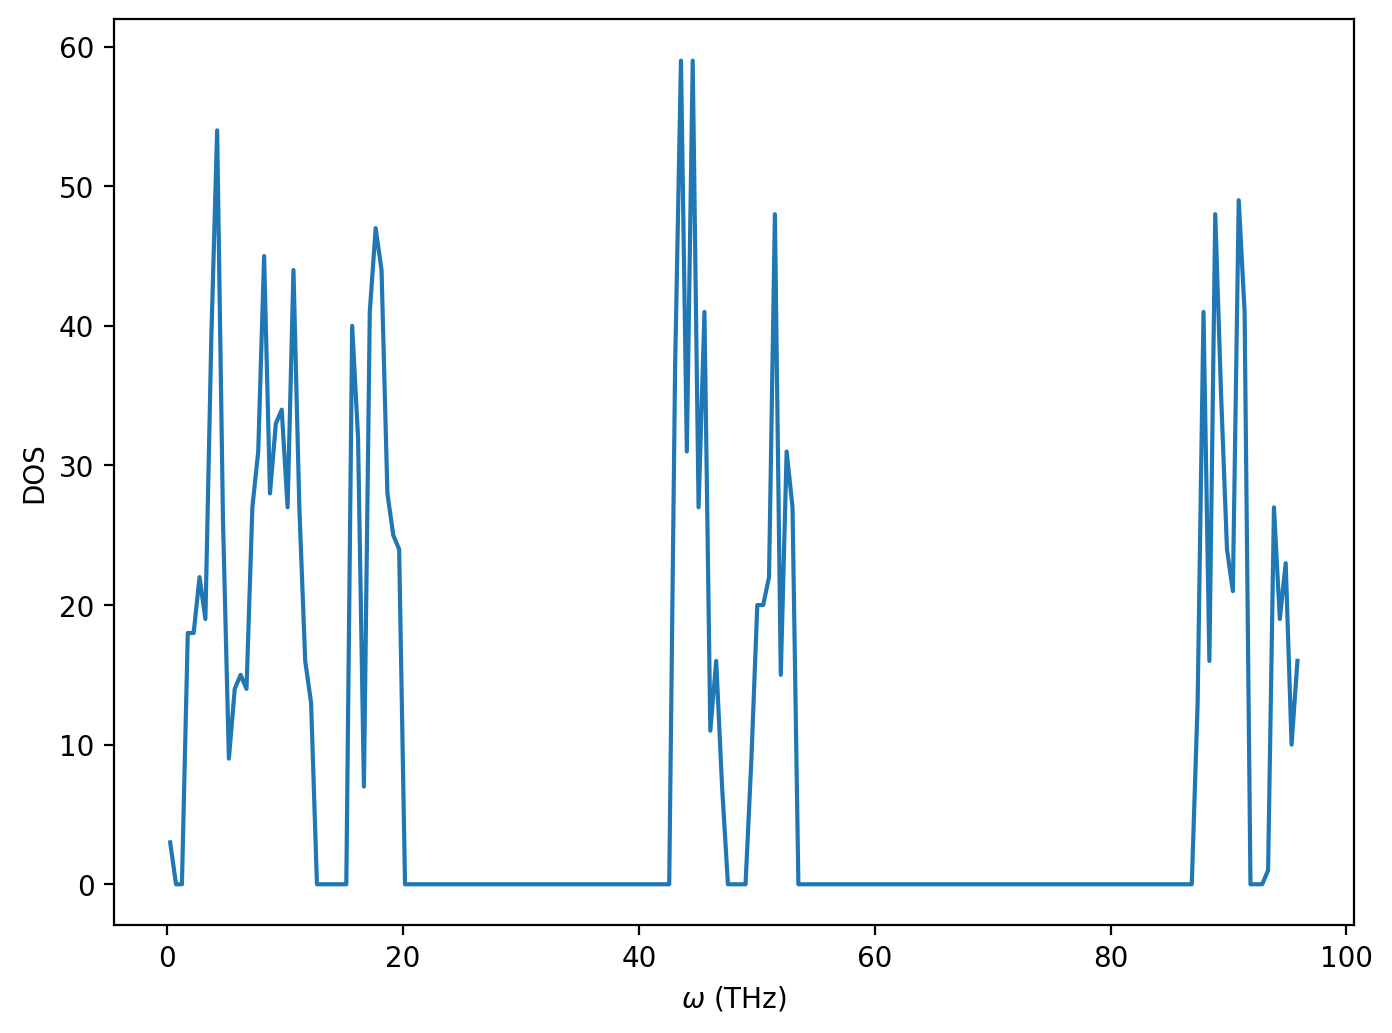

In [157]:
plt.figure(figsize=(8,6),dpi=200)
data=np.loadtxt('{}/disp-conf/200_{}/frequency.dat'.format(path,0.965))
plot_frequency_distribution(data[:,1], 0.5,0.965)
plt.ylabel('DOS')
plt.xlabel('$\omega$ (THz)')


Text(0.5, 0, '$\\omega$ (THz)')

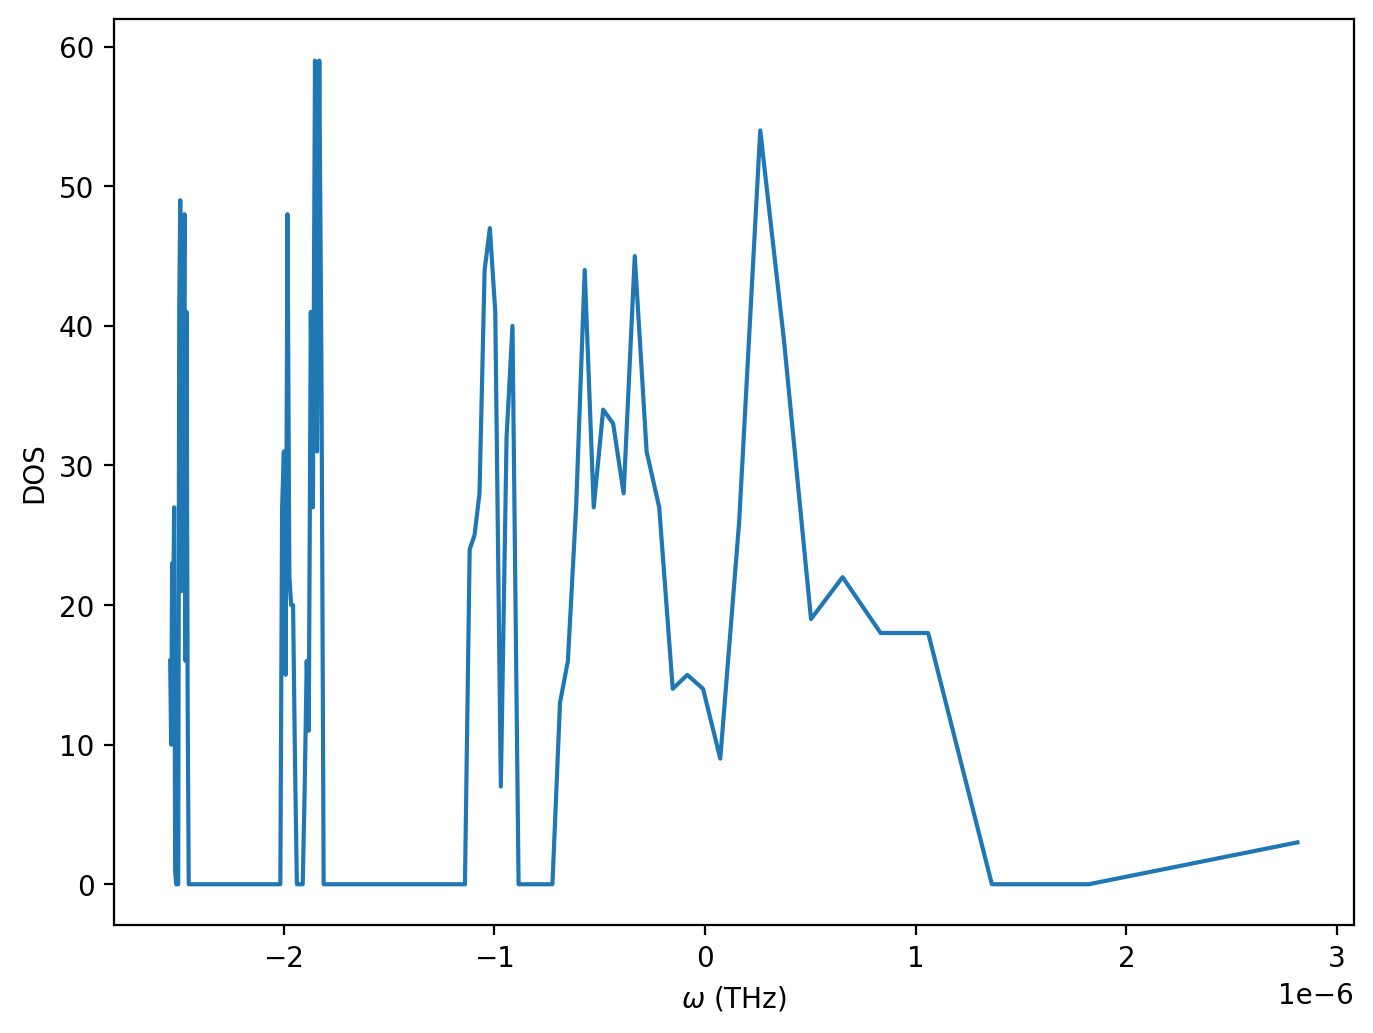

In [160]:
plt.figure(figsize=(8,6),dpi=200)
plt.plot(S2(N,100,bin_centers),counts)
plt.ylabel('DOS')
plt.xlabel('$\omega$ (THz)')

Text(0.5, 0, '$S$ (eV/K)')

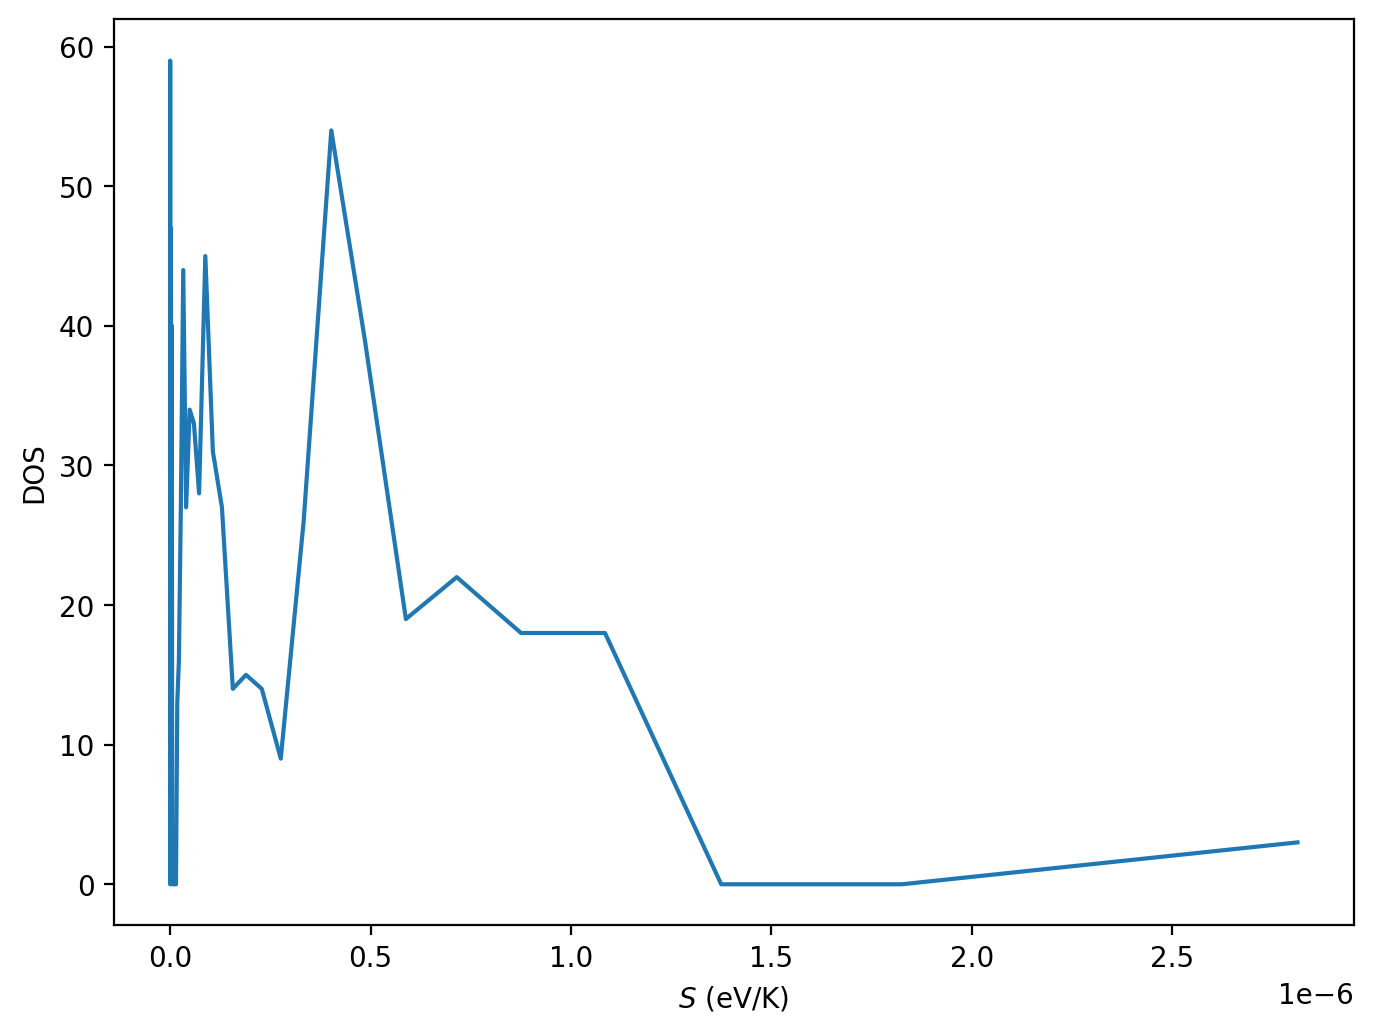

In [162]:
plt.figure(figsize=(8,6),dpi=200)
plt.plot(S2_qm(N,100,bin_centers),counts)
plt.ylabel('DOS')
plt.xlabel('$S$ (eV/K)')

In [709]:
def A_vib(T,data):
    RT=8.314*T #J/mol/K
    h=6.626*1e-34 #J*s
    nu=data[3:,1]*1e12 #1/s
    Na=6.02*1e23
    A=RT*np.sum(np.log( 2*np.sinh(h*nu*Na/2/RT) ))
    return A #J/mol

def A_vib_cl(T,data):
    RT=8.314*T #J/mol/K
    h=6.626*1e-34 #J*s
    nu=data[3:,1]*1e12 #1/s
    Na=6.02*1e23
    A=RT*np.sum(np.log(h*nu*Na/RT ))
    return A #J/mol


def pv(p,v):
    return p*1e5*v*1e-30*6.02*1e23

def Gibbs(N,T,data,p,v,u):
    return (A_vib(T,data)+pv(p,v))/N/1000/96.48+u/N

def Gibbs_cl(N,T,data,p,v,u):
    return (A_vib_cl(T,data)+0*pv(p,v))/N/1000/96.48+u/N

def Helm(N,T,data,v,u):
    return (A_vib(T,data))/N/1000/96.48+u/N

def S(N,T,data):
    R=8.314
    RT=8.314*T
    h=6.626*1e-34 #J*s
    nu=data[3:,1]*1e12 #1/s
    Na=6.02*1e23
    return R*np.sum(1-np.log(h*nu*Na/RT))/N/1000/96.48

def S_qm(N,T,data):
    R=8.314
    RT=8.314*T
    h=6.626*1e-34 #J*s
    nu=data[3:,1]*1e12 #1/s
    Na=6.02*1e23
    beta_h_nu=h*nu*Na/RT/2
    return R* np.sum((beta_h_nu/np.tanh(beta_h_nu) -np.log(2*np.sinh(beta_h_nu))))/N/1000/96.48

def S2(N,T,data):
    R=8.314
    RT=8.314*T
    h=6.626*1e-34 #J*s
    nu=data*1e12 #1/s
    Na=6.02*1e23
    return R*(1-np.log(h*nu*Na/RT))/N/1000/96.48

def S2_qm(N,T,data):
    R=8.314
    RT=8.314*T
    h=6.626*1e-34 #J*s
    nu=data*1e12 #1/s
    Na=6.02*1e23
    beta_h_nu=h*nu*Na/RT/2
    return R* (beta_h_nu/np.tanh(beta_h_nu) -np.log(2*np.sinh(beta_h_nu)))/N/1000/96.48

def ZPE(N,data):
    h=6.626*1e-34 #J*s
    nu=data[3:,1]*1e12 #1/s
    Na=6.02*1e23
    return np.sum(h*nu/2)*Na/N/1000/96.48
    

In [723]:
path='/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/II_new'

In [724]:
vol=np.loadtxt('{}/volume.txt'.format(path))[:,1]
u=np.loadtxt('{}/potential.txt'.format(path))[:,1]


In [725]:
dire=np.loadtxt('{}/volume.txt'.format(path))[:,0]
npoints=len(vol)
Temp=np.arange(100,600,100)
isobar_II=np.zeros((npoints,len(Temp)), dtype=float)
Anharmonic_F=np.zeros((npoints,len(Temp)), dtype=float)
N=576/6

S_II=np.zeros((npoints,len(Temp)), dtype=float)
pressure=17000 #bar
for i in range(npoints):
    fnm='{}/disp-conf/200_{}/frequency.dat'.format(path,dire[i])
    data=np.loadtxt(fnm)
    for j in range(len(Temp)):
        isobar_II[i,j]=Gibbs_cl(N,Temp[j],data,pressure,vol[i],u[i])
        S_II[i,j]=S_qm(N,Temp[j],data)
        
    

Text(0.5, 1.0, 'phase II, p=17000 bar')

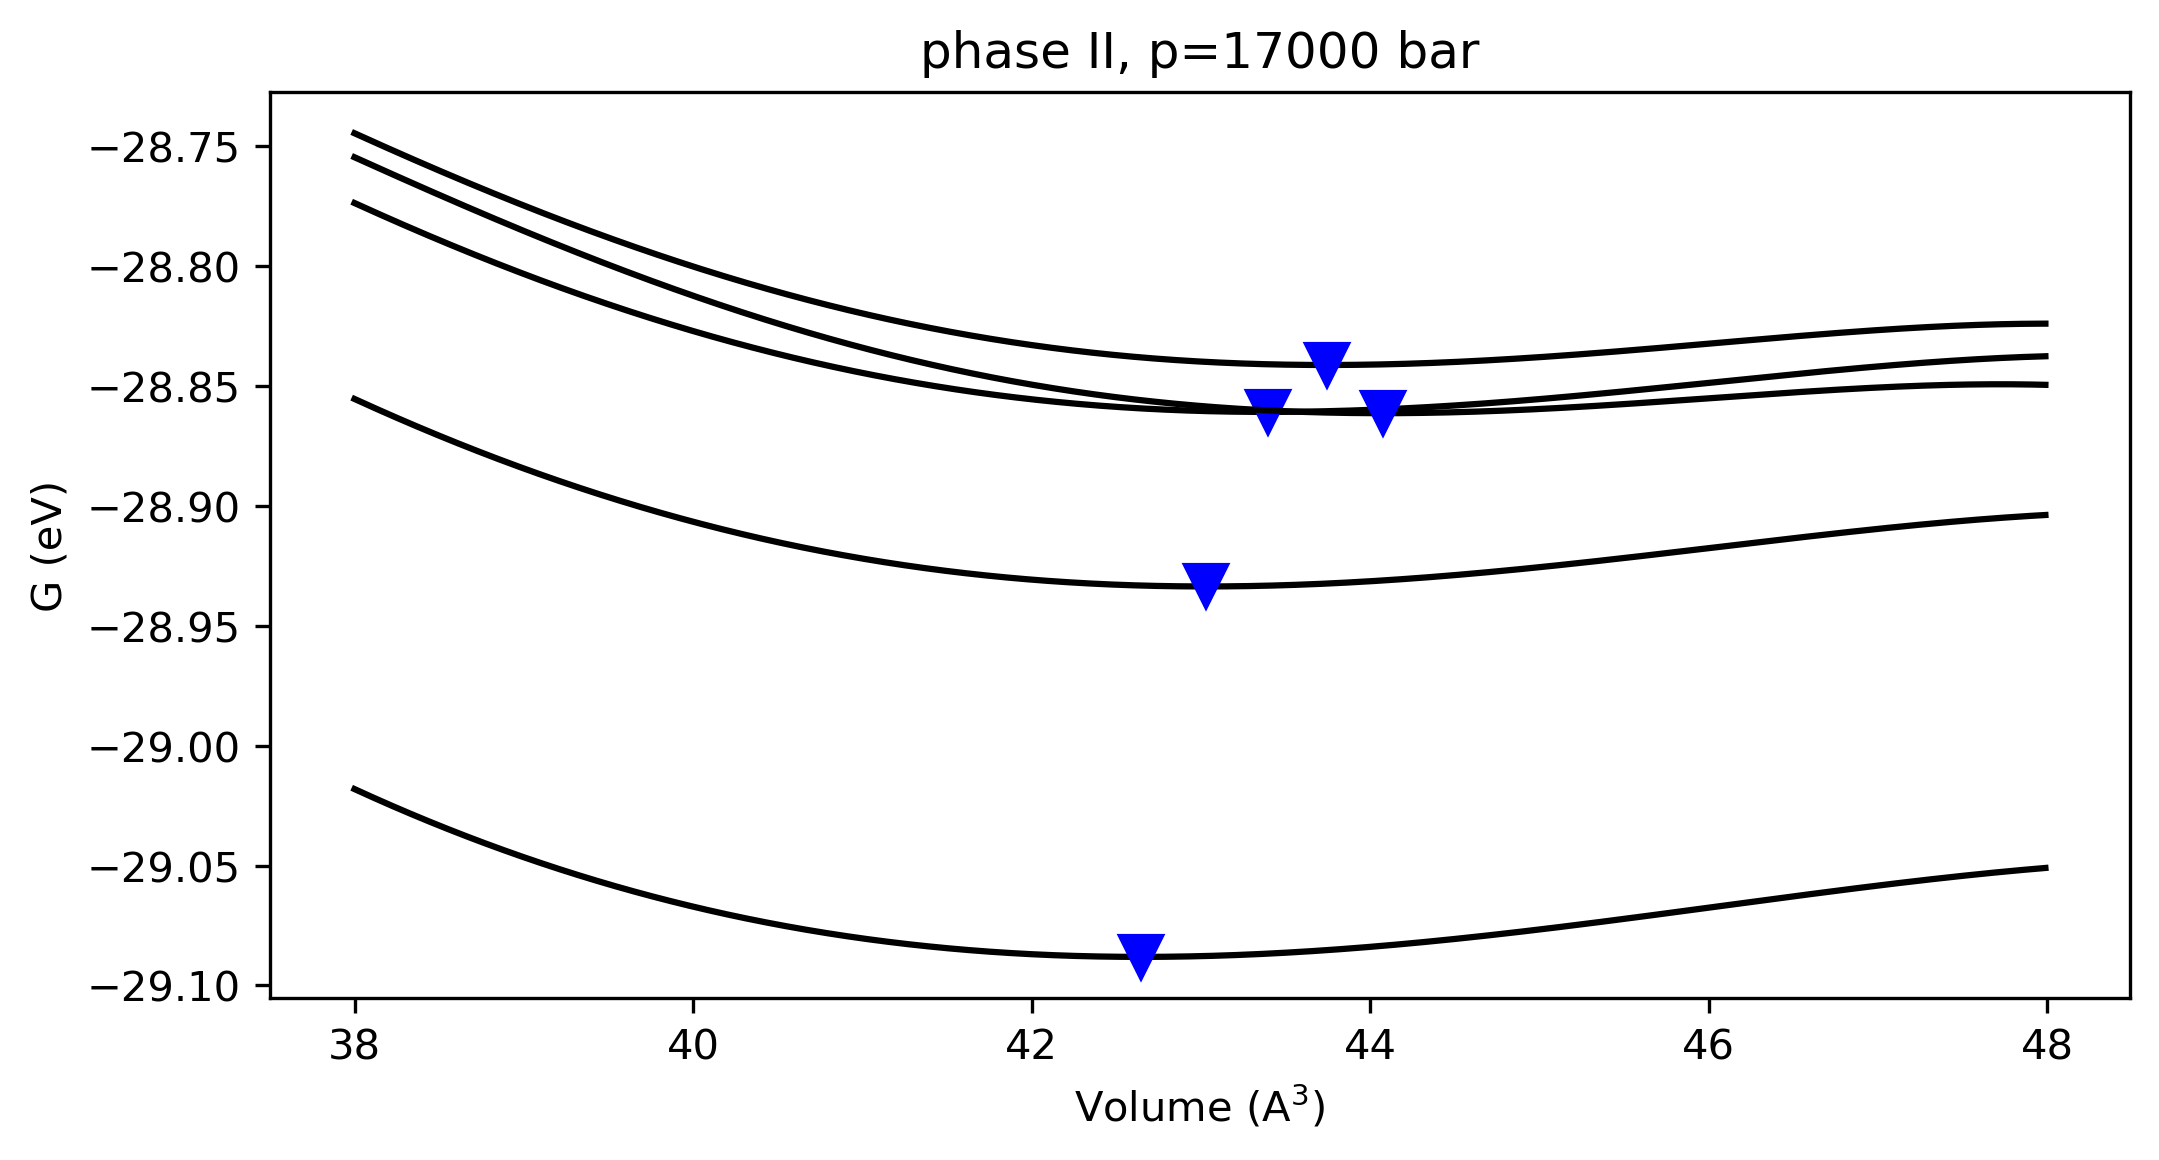

In [726]:
plt.figure(figsize=(8,4),dpi=300)
Gibbs_T_II=np.zeros((len(Temp),2),dtype=float)
for j in range(len(Temp)):
    #plt.plot(vol[:]/N,isobar_II[:,j],'kx')
    fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_II[:,j], 4))  
    plt.plot(np.arange(38,48,0.01),fitting(np.arange(38,48,0.01)),'-k')
    root=np.roots(fitting.deriv())[1]
    plt.plot(root,fitting(root),'bv', ms=10)
    Gibbs_T_II[j,0]=Temp[j]
    Gibbs_T_II[j,1]=fitting(root)
#print(50,fitting(42.90784787))
#Gibbs_T[0,0]=50
#Gibbs_T[0,1]=fitting(42.90784787)

plt.xlabel('Volume (A$^3$)')
plt.ylabel('G (eV)')
plt.title('phase II, p={} bar'.format(pressure))

Text(0.5, 1.0, 'p=17000 bar')

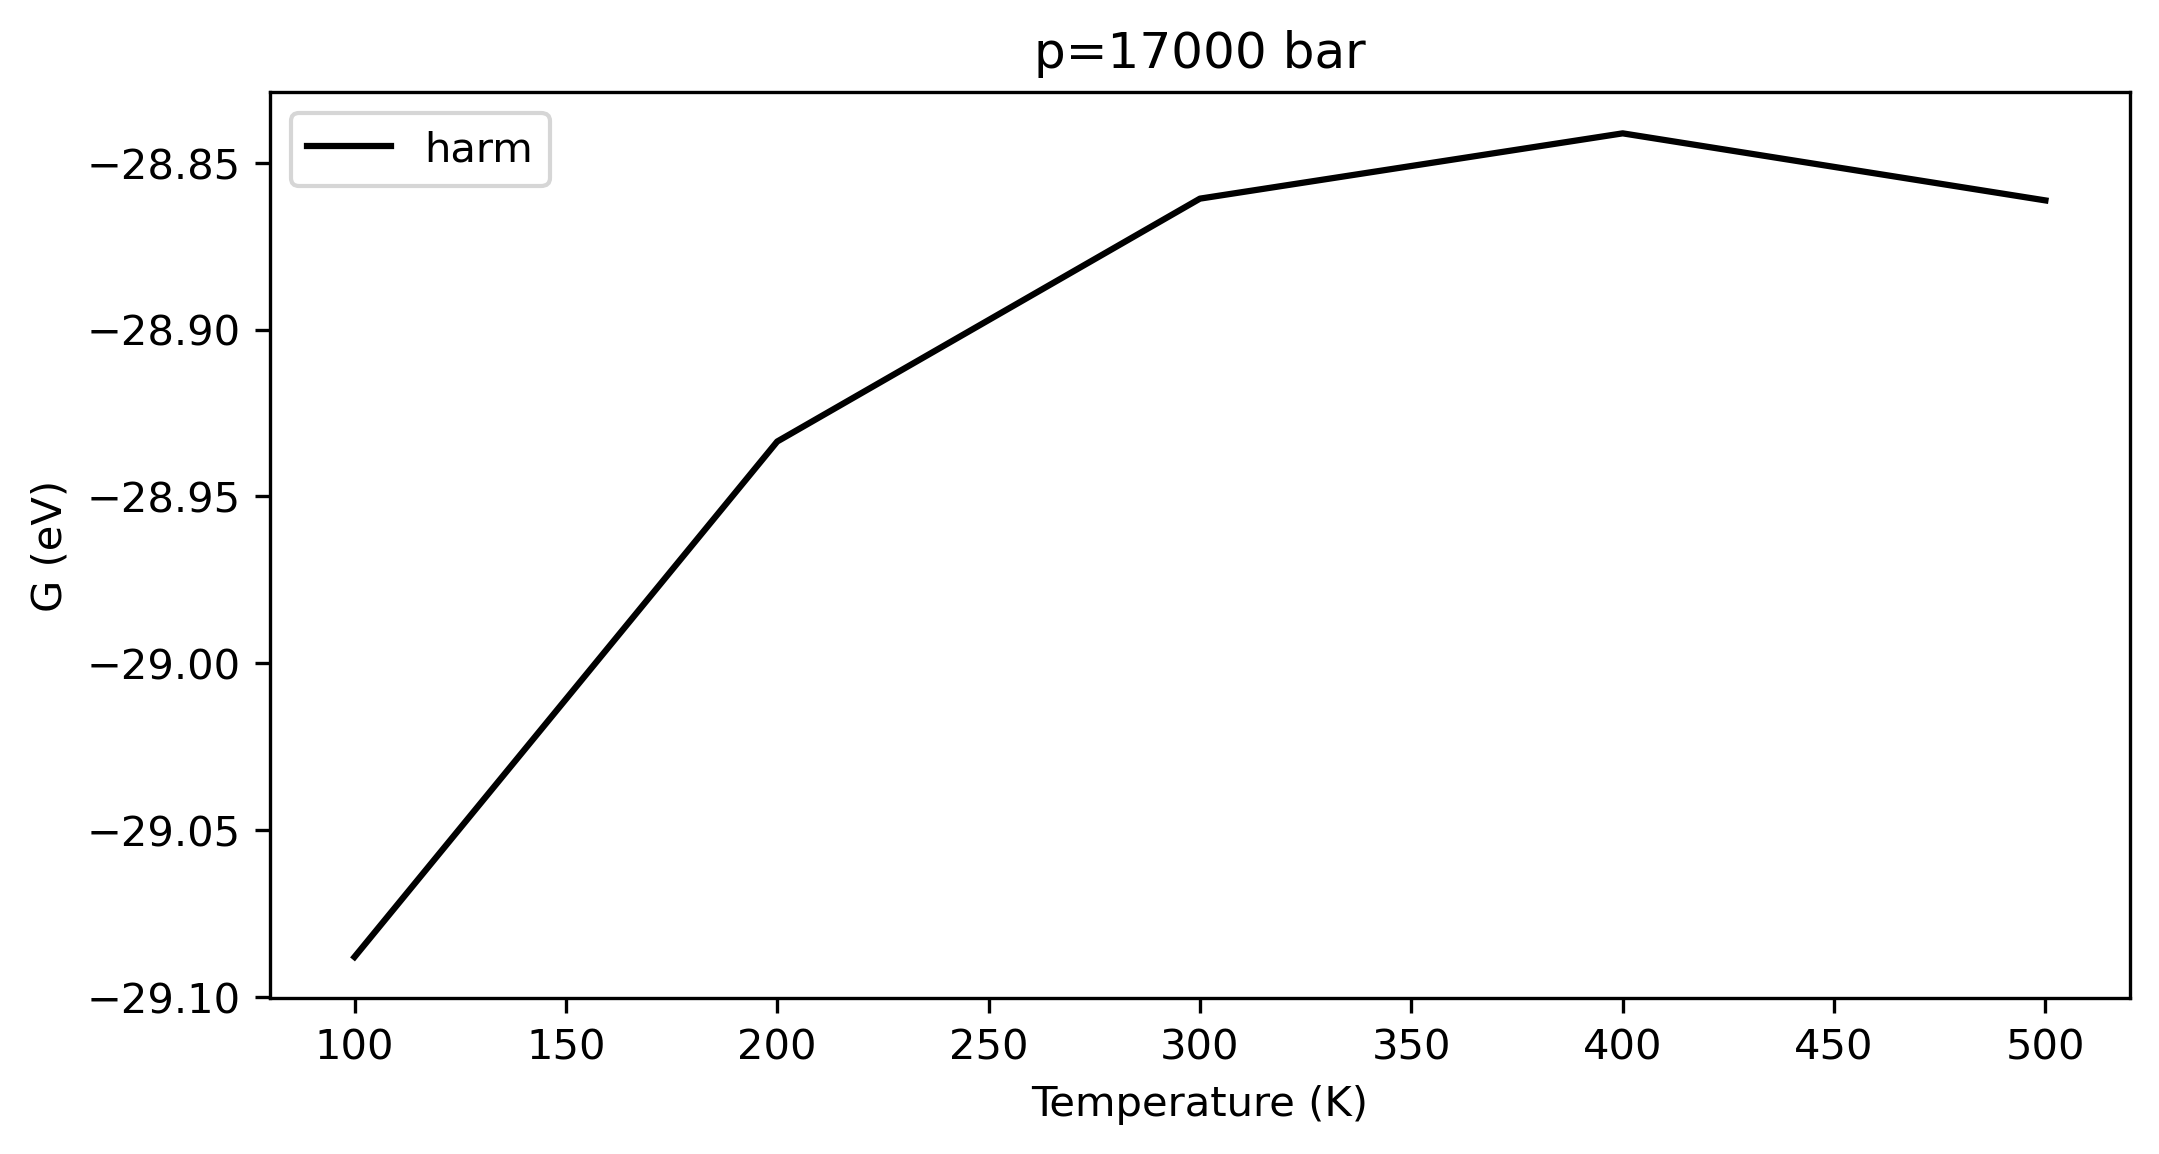

In [727]:
plt.figure(figsize=(8,4),dpi=300)
plt.plot(Gibbs_T_II[:,0], Gibbs_T_II[:,1],'k-',label='harm')
plt.xlabel('Temperature (K)')
plt.legend()
plt.ylabel('G (eV)')
plt.title('p={} bar'.format(pressure))

[-5.67563964e-06  2.75887687e-07 -1.32931647e-09  3.27920439e-12
 -1.99450766e-15 -8.25356040e-19]
[ 1.39067323e-05 -2.45347238e-07  3.20558828e-09 -1.40382517e-11
  2.81998478e-14 -2.05278218e-17]
[ 4.30551015e-06  4.86850750e-08  1.54588294e-10 -1.50242504e-13
 -1.12929894e-16  6.93342152e-19]
[ 8.86438564e-06 -1.17214760e-07  2.06066707e-09 -8.69015428e-12
  1.64596112e-14 -1.09320129e-17]
[ 6.97457990e-06 -3.40344386e-09  1.20957433e-09 -6.45621563e-12
  1.49218456e-14 -1.15311190e-17]
[ 1.26256655e-05 -1.06052162e-07  2.07074124e-09 -8.21132306e-12
  1.49197892e-14 -8.97318423e-18]


(-0.02, 0.06)

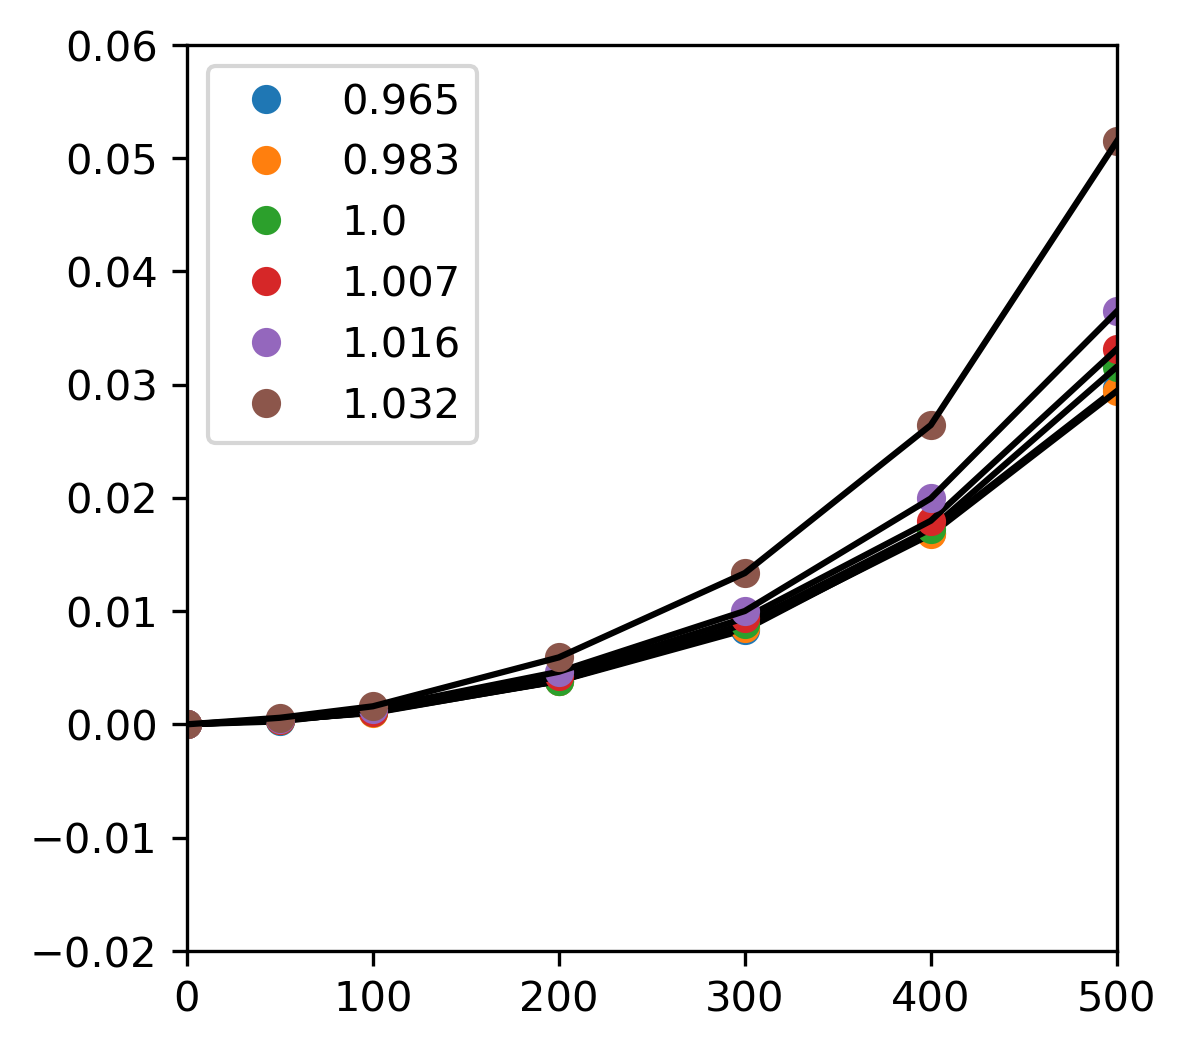

In [729]:

from scipy.optimize import curve_fit
def fitting_func(x, k1,k2,k3,k4,k5,k6):
    return k1*x + k2*x**2 + k3*x**3 + k4*x**4 + k5*x**5 + k6*x**6
def F_anharm(x,k1,k2,k3,k4,k5,k6):
    return -1*x*(k1*np.log(x) + k2*x + (k3/2)*x**2 + (k4/3)*x**3 + (k5/4)*x**4 + (k6/5)*x**5)


plt.figure(figsize=(4,4),dpi=300)
for i in range(npoints):
    data=np.loadtxt('{}/anharmonic/{}.dat'.format(path,dire[i]))
    T_=data[:7,0]
    Uh=(3*576*8.314*data[:7,0])/1000/96.48/2
    Uq=data[0,1]
    Ua=data[:7,1]-Uq-Uh
    plt.plot(T_,Ua/N/T_**0,'o',label='{}'.format(dire[i]))
    popt, pcov = curve_fit(fitting_func, T_, Ua/N, p0=[7.1e-05, 1.06e-05, -1.628e-08,3.806e-11,3.806e-11,3.806e-11])  # p0 是初始猜测值
    k = popt[:]
    y_fit = fitting_func(T_, k[0],k[1],k[2],k[3],k[4],k[5])
    plt.plot(T_, y_fit/T_**0, 'k-')
    Anharmonic_F[i,:]=F_anharm(Temp,k[0],k[1],k[2],k[3],k[4],k[5])
    print(k)

#plt.plot(data[:,0],(3*576*8.314*data[:,0])/1000/96.48/2,'--k')
    
plt.legend()
plt.xlim(0,500)
plt.ylim(-0.02,0.06)

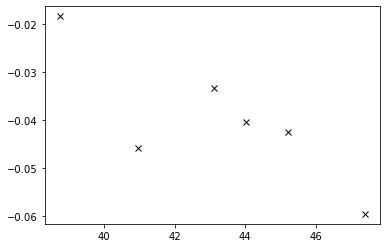

In [705]:
plt.plot(vol[:]/N,Anharmonic_F[:,j],'kx')

Text(0.5, 1.0, 'phase II with anharmonic term, p=17000 GPa')

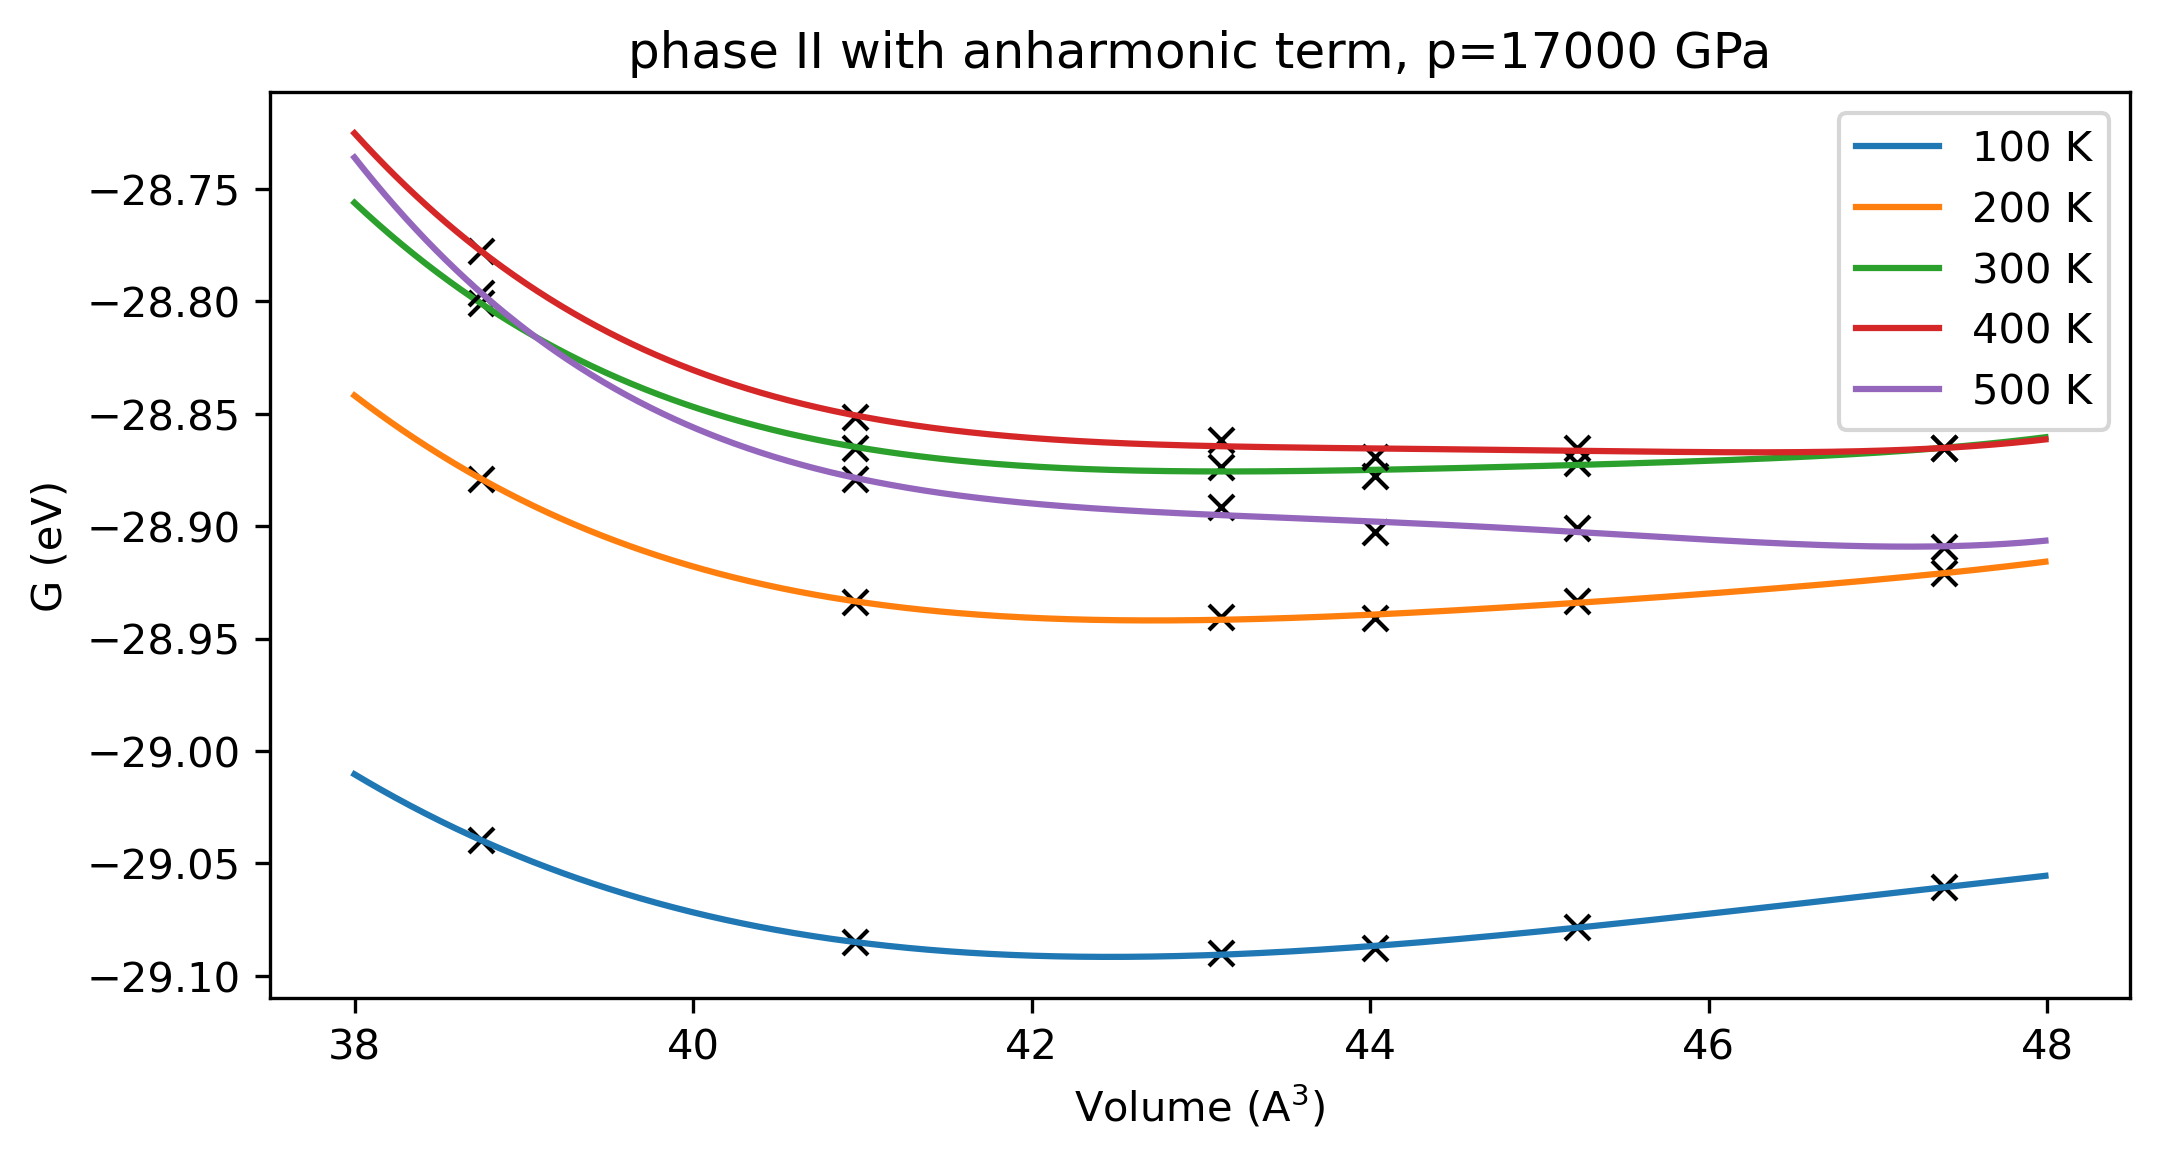

In [706]:
plt.figure(figsize=(8,4),dpi=300)
Gibbs_T_II_anh=np.zeros((len(Temp),2),dtype=float)
for j in range(len(Temp)):
    plt.plot(vol[:]/N,isobar_II[:,j]+Anharmonic_F[:,j],'kx')
    fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_II[:,j]+Anharmonic_F[:,j], 4))  
    plt.plot(np.arange(38,48,0.01),fitting(np.arange(38,48,0.01)),'-',label='{} K'.format(Temp[j]))
    #root_list=np.roots(fitting.deriv())
    #root=root_list[(root_list.real > 40) & (root_list.real < 44) & (root_list.imag==0)]
    #print(root)
    #plt.plot(root.real,fitting(root.real),'bv', ms=10)
    #Gibbs_T_II_anh[j,0]=Temp[j]
    #Gibbs_T_II_anh[j,1]=fitting(root.real)
#print(50,fitting(42.90784787))
#Gibbs_T[0,0]=50
#Gibbs_T[0,1]=fitting(42.90784787)

plt.legend()
plt.xlabel('Volume (A$^3$)')
plt.ylabel('G (eV)')
plt.title('phase II with anharmonic term, p={} GPa'.format(pressure))

Text(0.5, 0, 'T (K)')

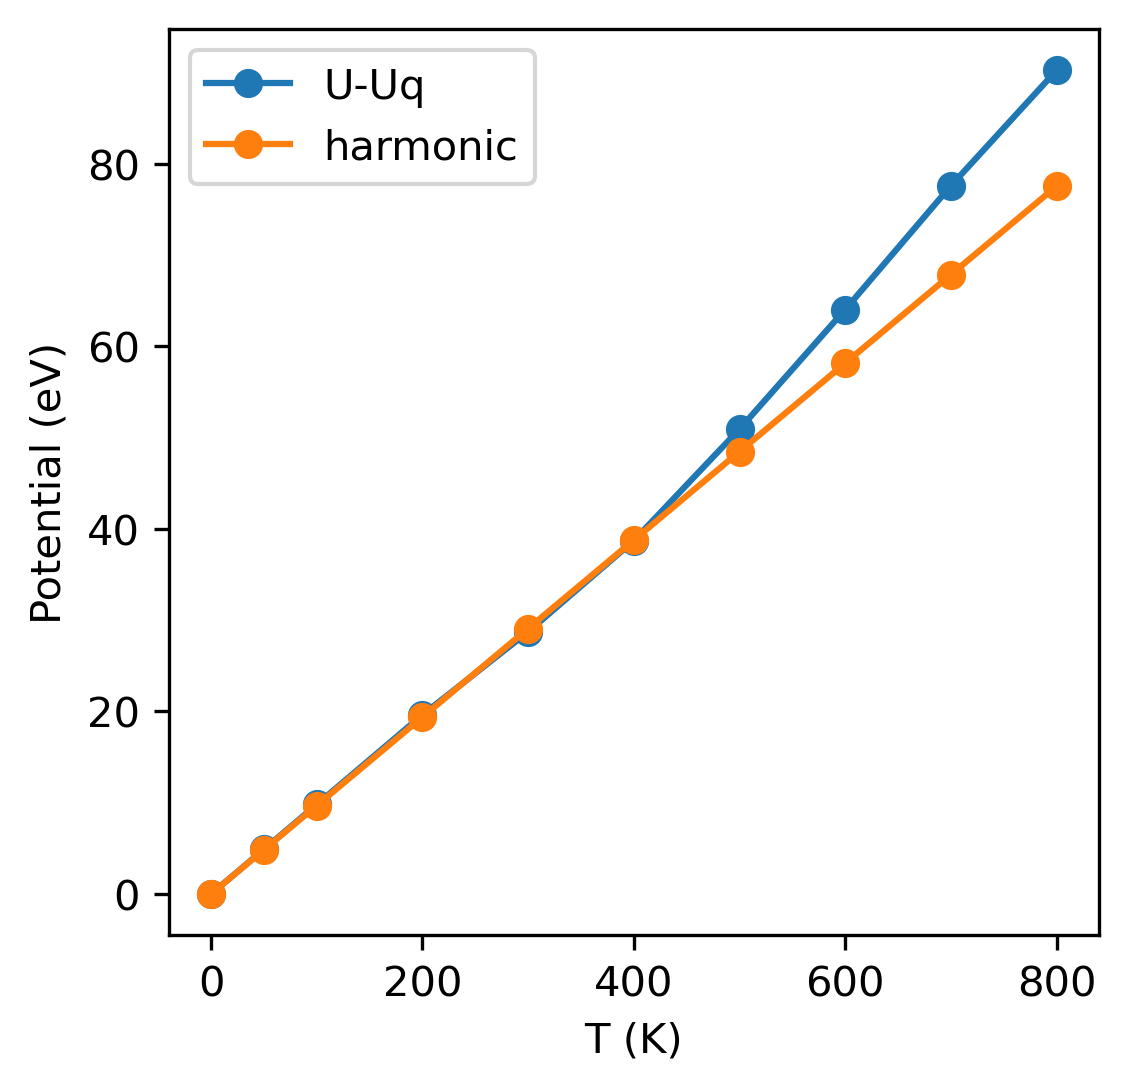

In [361]:
plt.figure(figsize=(4,4),dpi=300)
plt.plot(T_, Ua+Uh,'-o',label='U-Uq')
plt.plot(T_, Uh,'-o',label='harmonic')
plt.legend()
plt.ylabel('Potential (eV)')
plt.xlabel('T (K)')

[ 1.12446288e-06  1.08165665e-07 -1.64853845e-10  3.93024710e-13]


Text(0.5, 0, 'T')

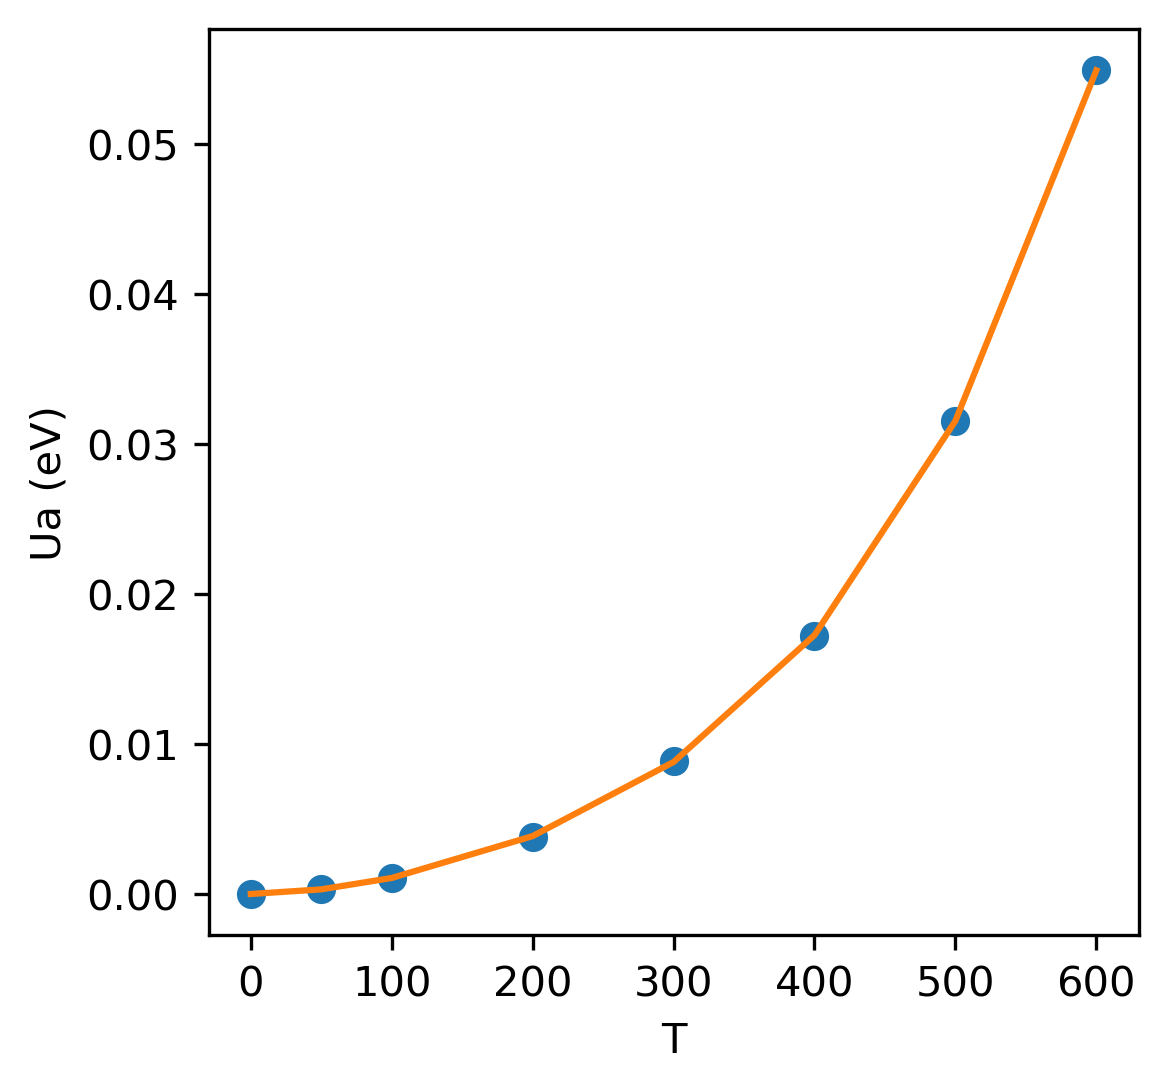

In [285]:
plt.figure(figsize=(4,4),dpi=300)
plt.plot(T_, Ua/N,'o')
from scipy.optimize import curve_fit
def fitting_func(x, k1,k2,k3,k4):
    return k1*x + k2*x**2 + k3*x**3 + k4*x**4
popt, pcov = curve_fit(fitting_func, T_, Ua/N, p0=[7.1e-05, 1.06e-05, -1.628e-08,3.806e-11])  # p0 是初始猜测值
k = popt[:]  # 提取斜率 k
y_fit = linear_func(T_, k[0],k[1],k[2],k[3])
plt.plot(T_, y_fit, '-')
print(k)
def F_anharm(x,k1,k2,k3,k4):
    return -1*x*(k1*np.log(x) + k2*x + (k3/2)*x**2 + (k4/3)*x**3)

plt.ylabel('Ua (eV)')
plt.xlabel('T')

Text(0.5, 1.0, 'p=17000 bar')

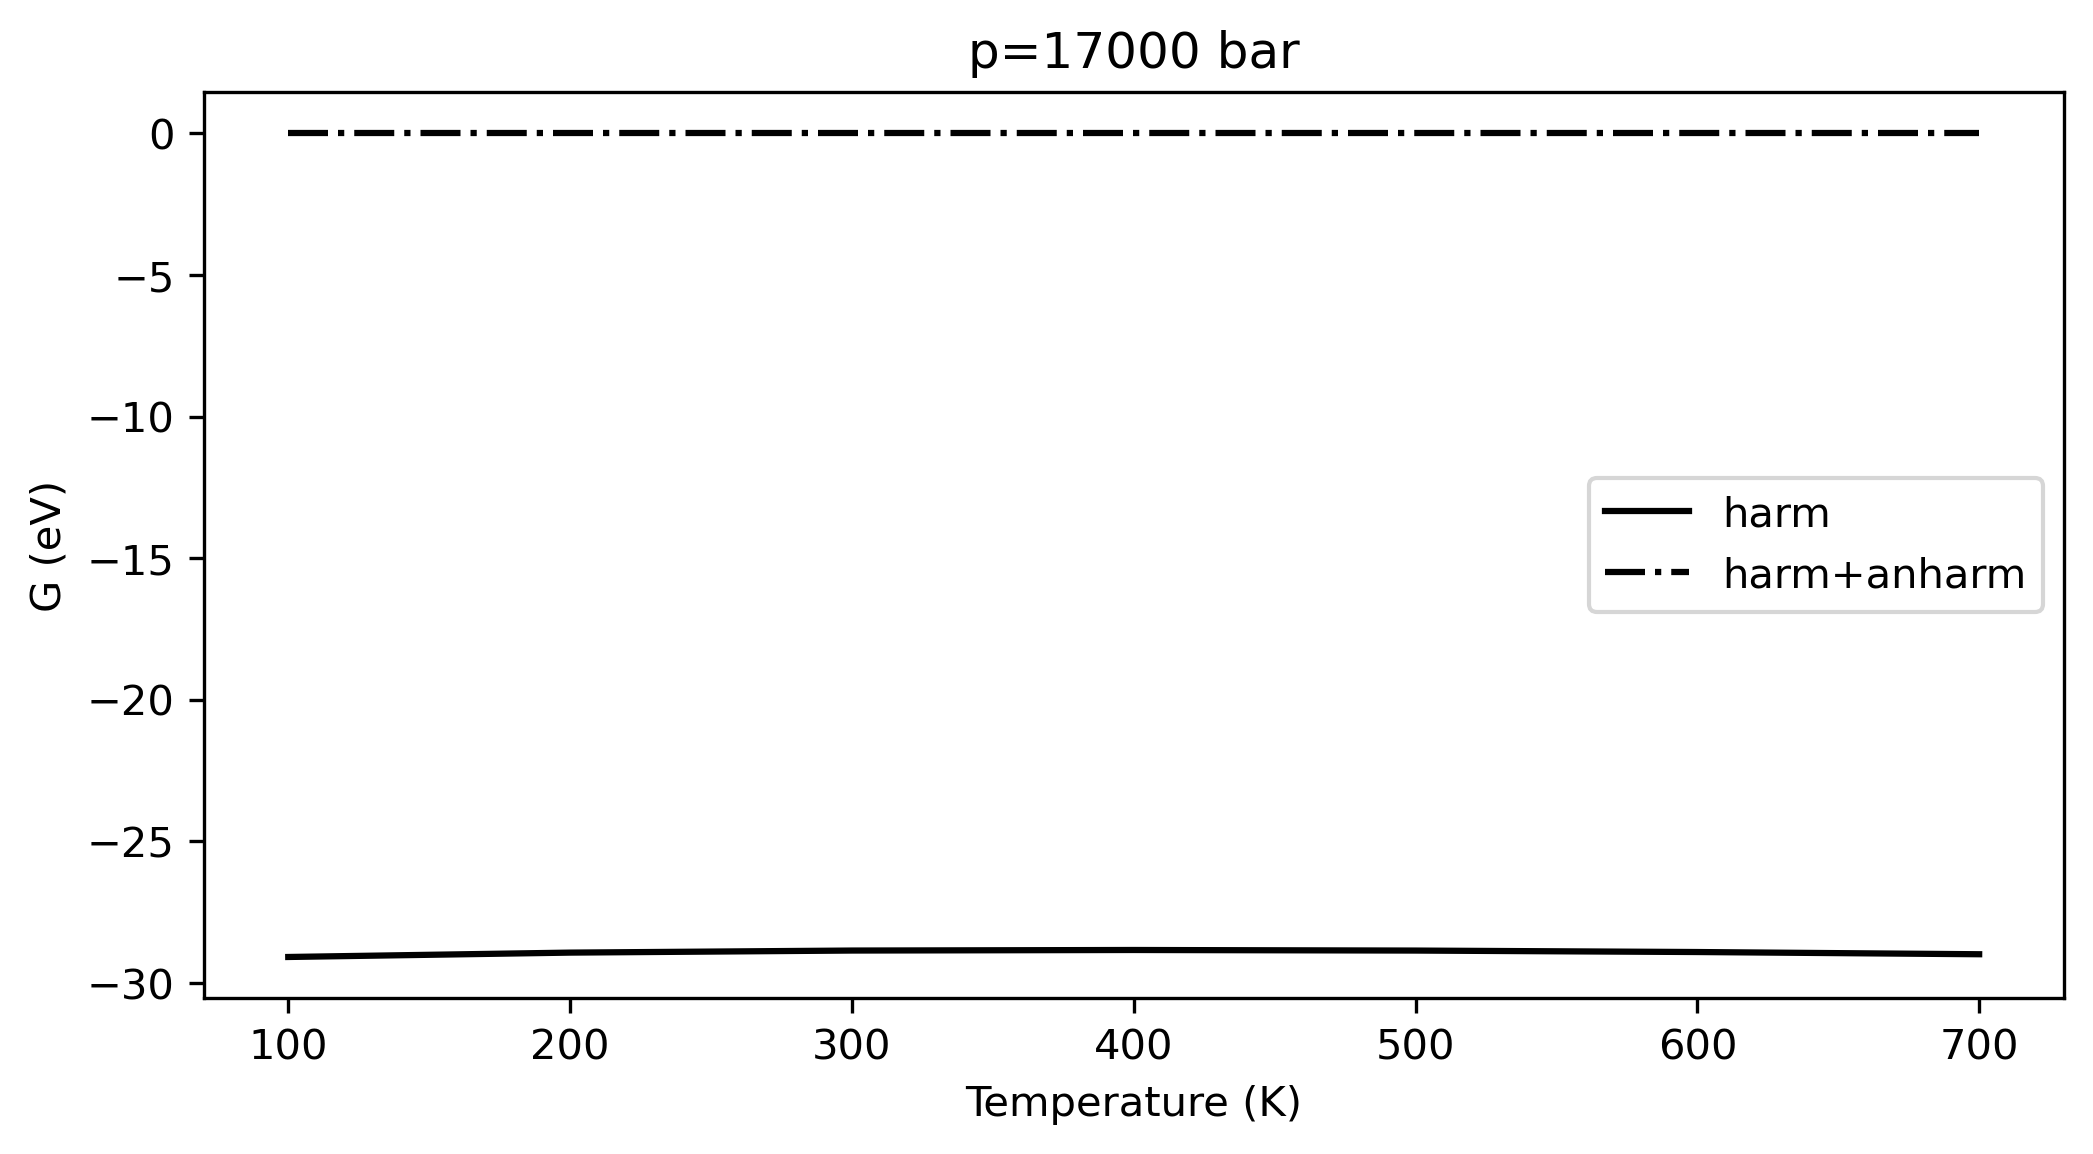

In [667]:
plt.figure(figsize=(8,4),dpi=300)
plt.plot(Gibbs_T_II[:,0], Gibbs_T_II[:,1],'k-',label='harm')
plt.plot(Gibbs_T_II[:,0], Gibbs_T_II_anh[:,1],'k-.',label='harm+anharm')
plt.xlabel('Temperature (K)')
plt.legend()
plt.ylabel('G (eV)')
plt.title('p={} bar'.format(pressure))


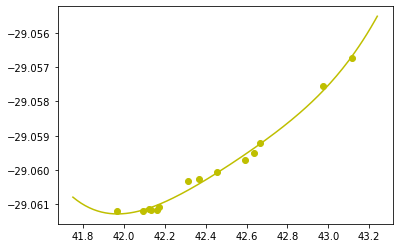

In [18]:
plt.plot(vol[:]/N,isobar_50K[:],'yo',label='50K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_50K[:,0], 4))  
plt.plot(np.arange(41.75,43.25,0.01),fitting(np.arange(41.75,43.25,0.01)),'-y')
#plt.plot(42.06997738,fitting(42.06997738),'yv', ms=10)

|T=100K  | V(A$^3$) | G (eV) |
|-------|-------|-------|
| HTI 0.2 GPa| 42.48 | -29.070755 |
| QHA+F$_{anh}$ 0.2 GPa| 42.48 | -29.136083 |



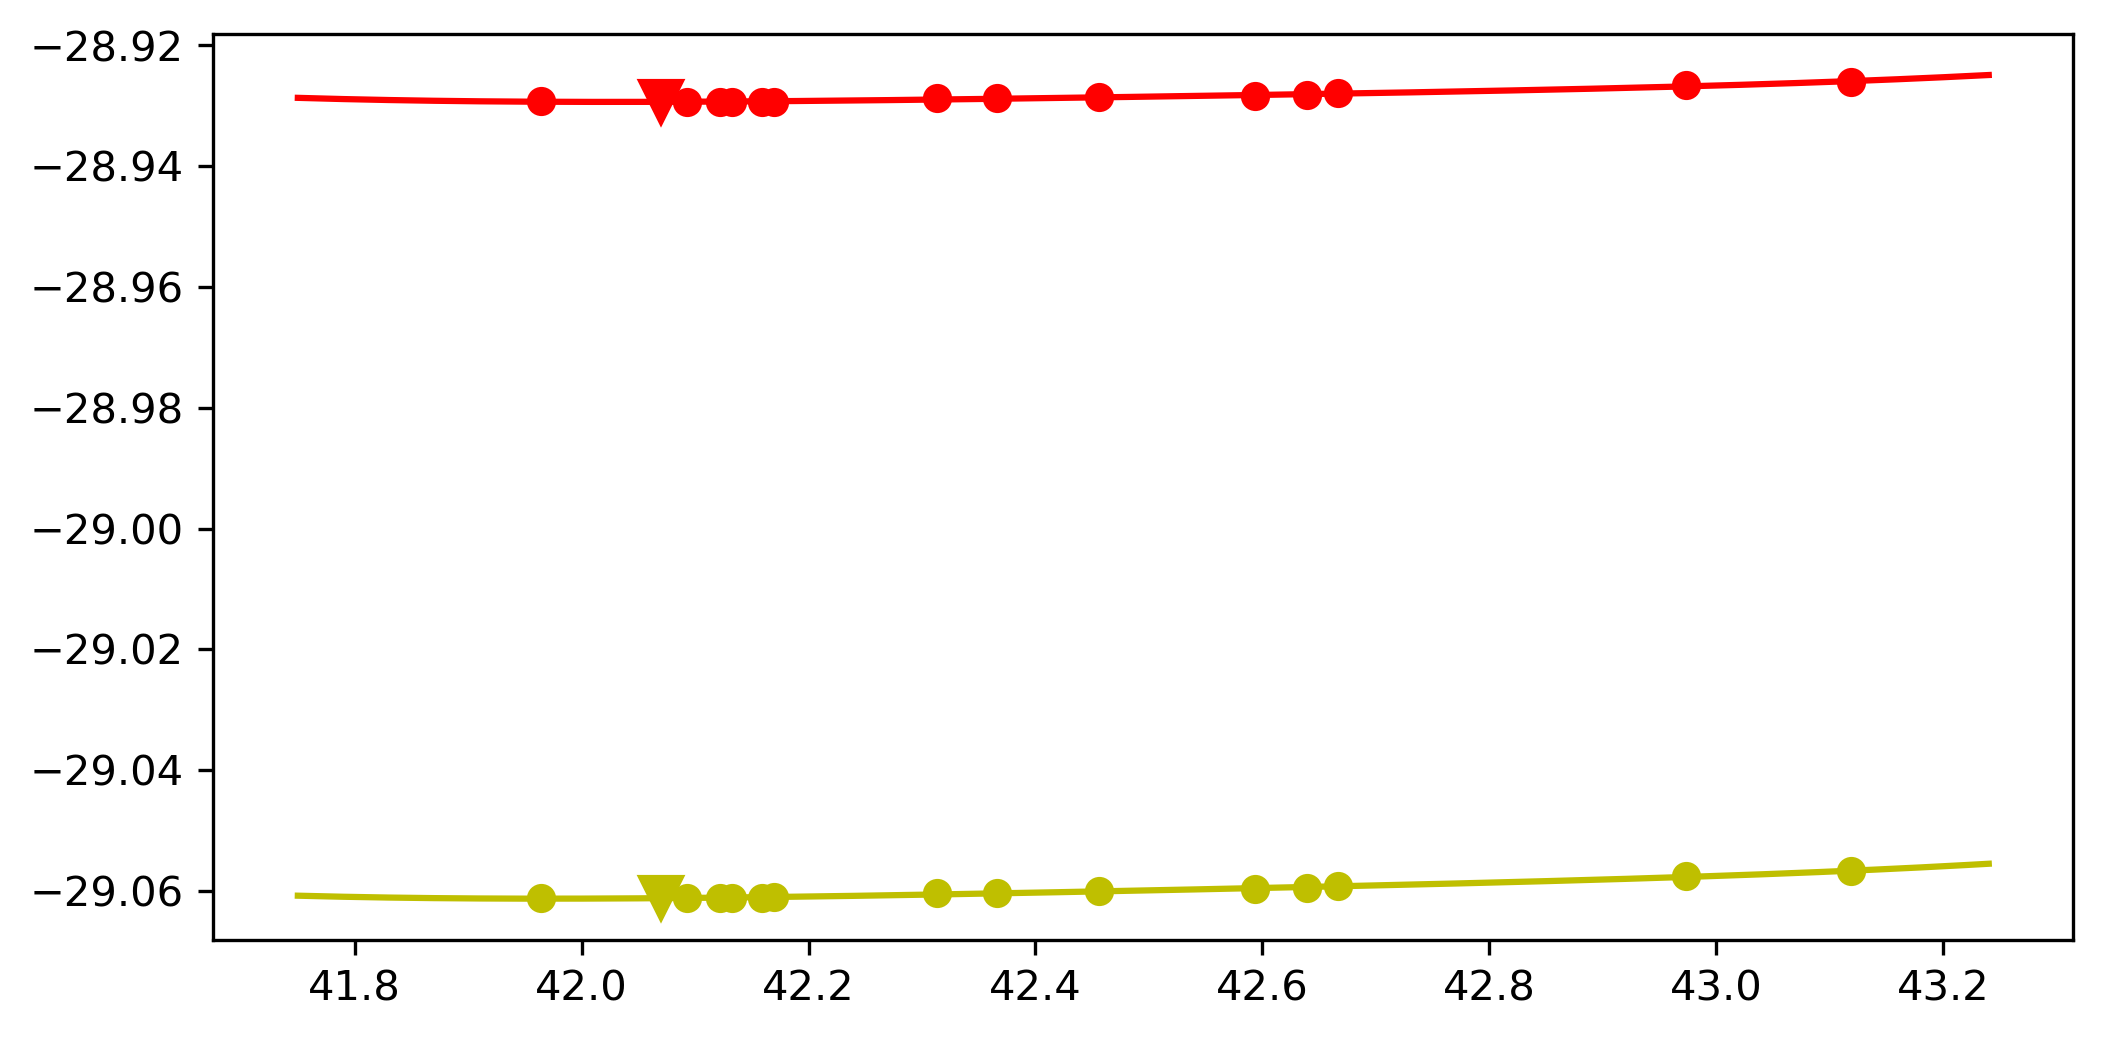

In [13]:
plt.figure(figsize=(8,4),dpi=300)
plt.plot(vol[:]/N,isobar_50K[:],'yo',label='50K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_50K[:,0], 4))  
plt.plot(np.arange(41.75,43.25,0.01),fitting(np.arange(41.75,43.25,0.01)),'-y')
plt.plot(42.06997738,fitting(42.06997738),'yv', ms=10)


plt.plot(vol[:]/N,isobar_100K[:],'ro',label='100K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_100K[:,0], 4))  
plt.plot(np.arange(41.75,43.25,0.01),fitting(np.arange(41.75,43.25,0.01)),'-r')
plt.plot(42.06997738,fitting(42.06997738),'rv', ms=10)

array([42.74101977+0.53464782j, 42.74101977-0.53464782j,
       42.06997738+0.j        ])

# III

In [67]:
vol=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/volume.txt')[:,1]
u=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/potential.txt')[:,1]

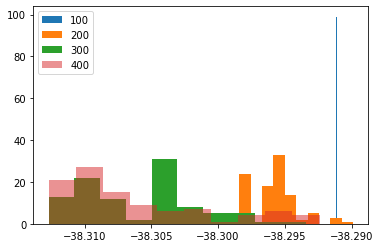

In [759]:
data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/100/pe.txt')
plt.hist(data,label='100')
data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/200/pe.txt')
plt.hist(data,label='200')
data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/300/pe.txt')
plt.hist(data,label='300')
data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/400/pe.txt')
plt.hist(data,alpha=0.5,label='400')
#data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/500/pe.txt')
#plt.hist(data, label='500')
#print('500',np.mean(data))
#data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/600/pe.txt')
#plt.hist(data, label='600')
#data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/700/pe.txt')
#plt.hist(data, label='700')
#data=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/800/pe.txt')
#plt.hist(data, label='800')

plt.legend()

Text(0, 0.5, '$\\Delta$<E$_{IS}$> (eV)')

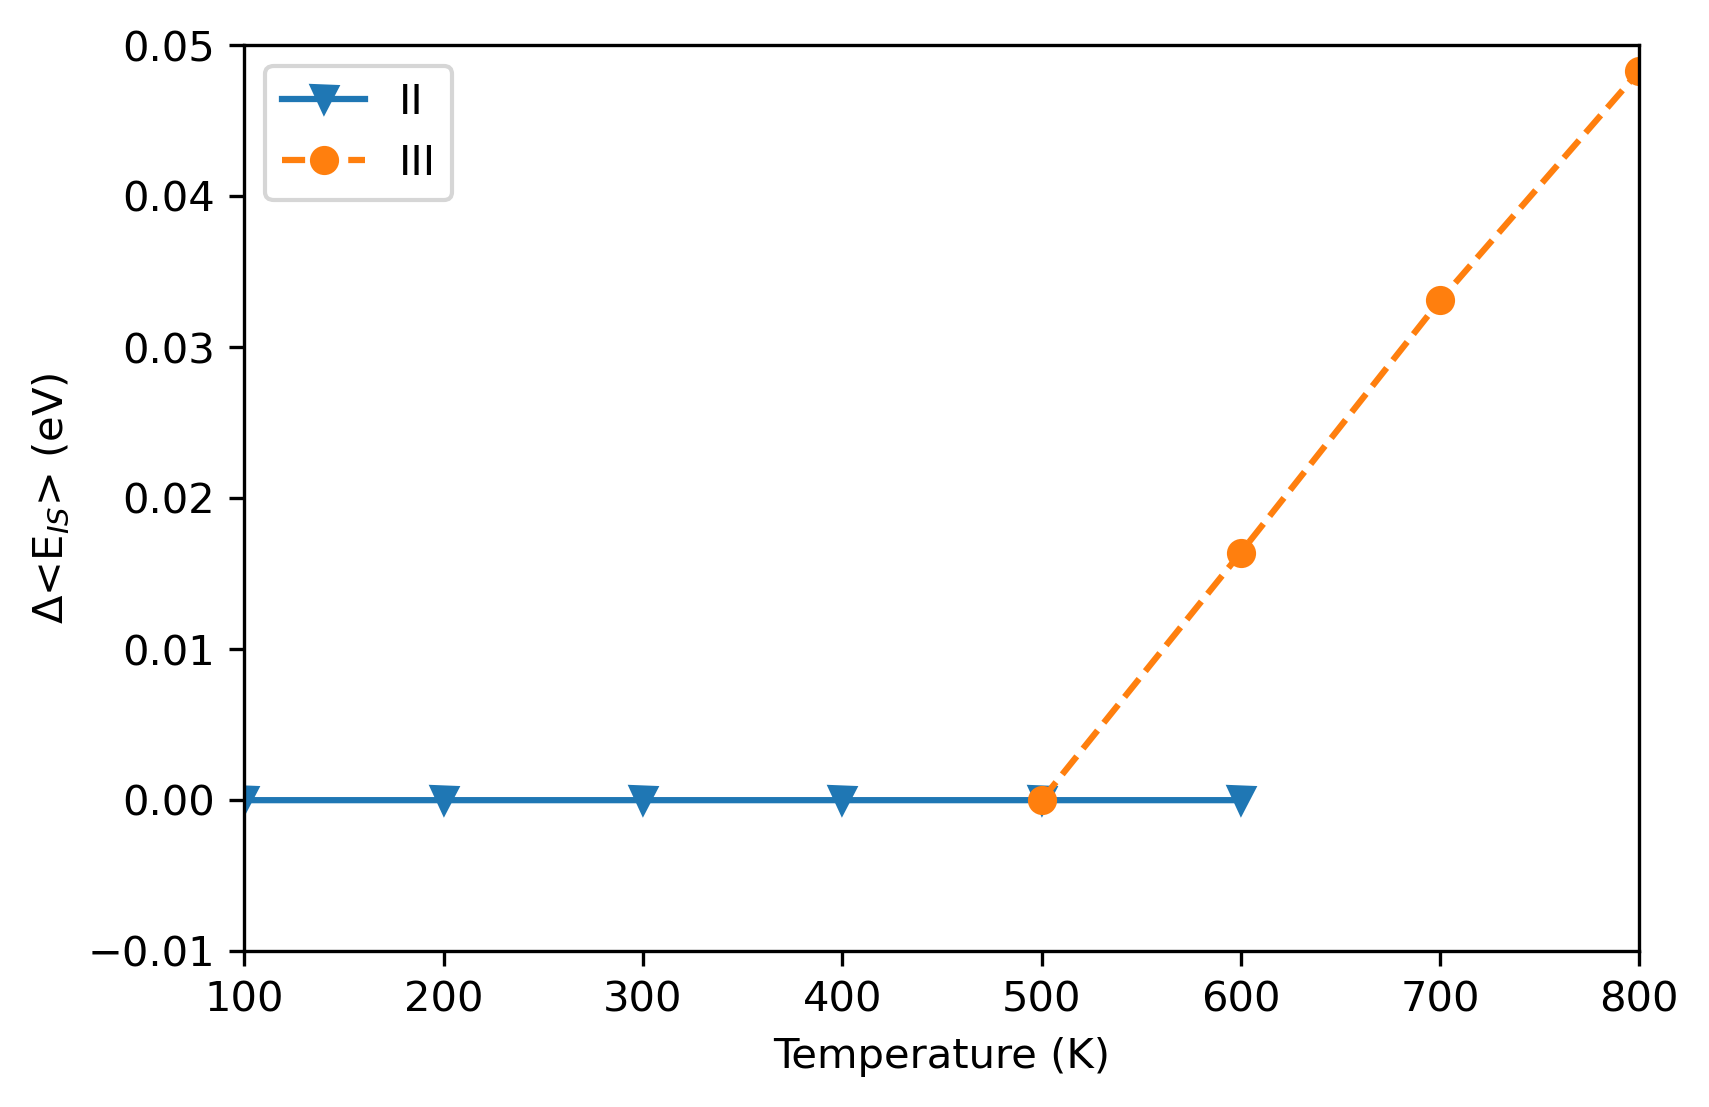

In [780]:
plt.figure(figsize=(6,4),dpi=300)

pe=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/II_new/Sconf/pe.txt')
plt.plot(pe[:,0],(pe[:,1]-pe[0,1])/576*6,'-v',label='II')

pe=np.loadtxt('/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III/Sconf/pe.txt')
plt.plot(pe[:,0],(pe[:,1]-pe[0,1]),'--o',label='III')
#fitting= np.poly1d(np.polyfit(pe[:,0],pe[:,1], 1))
#plt.plot(np.arange(400,600),fitting(np.arange(400,600)),'-y')
#print(fitting)

plt.legend()
plt.ylim(-0.01,0.05)
plt.xlim(100,800)
plt.xlabel('Temperature (K)')
plt.ylabel('$\Delta$<E$_{IS}$> (eV)')

Text(0, 0.5, '<E$_{IS}$> (eV)')

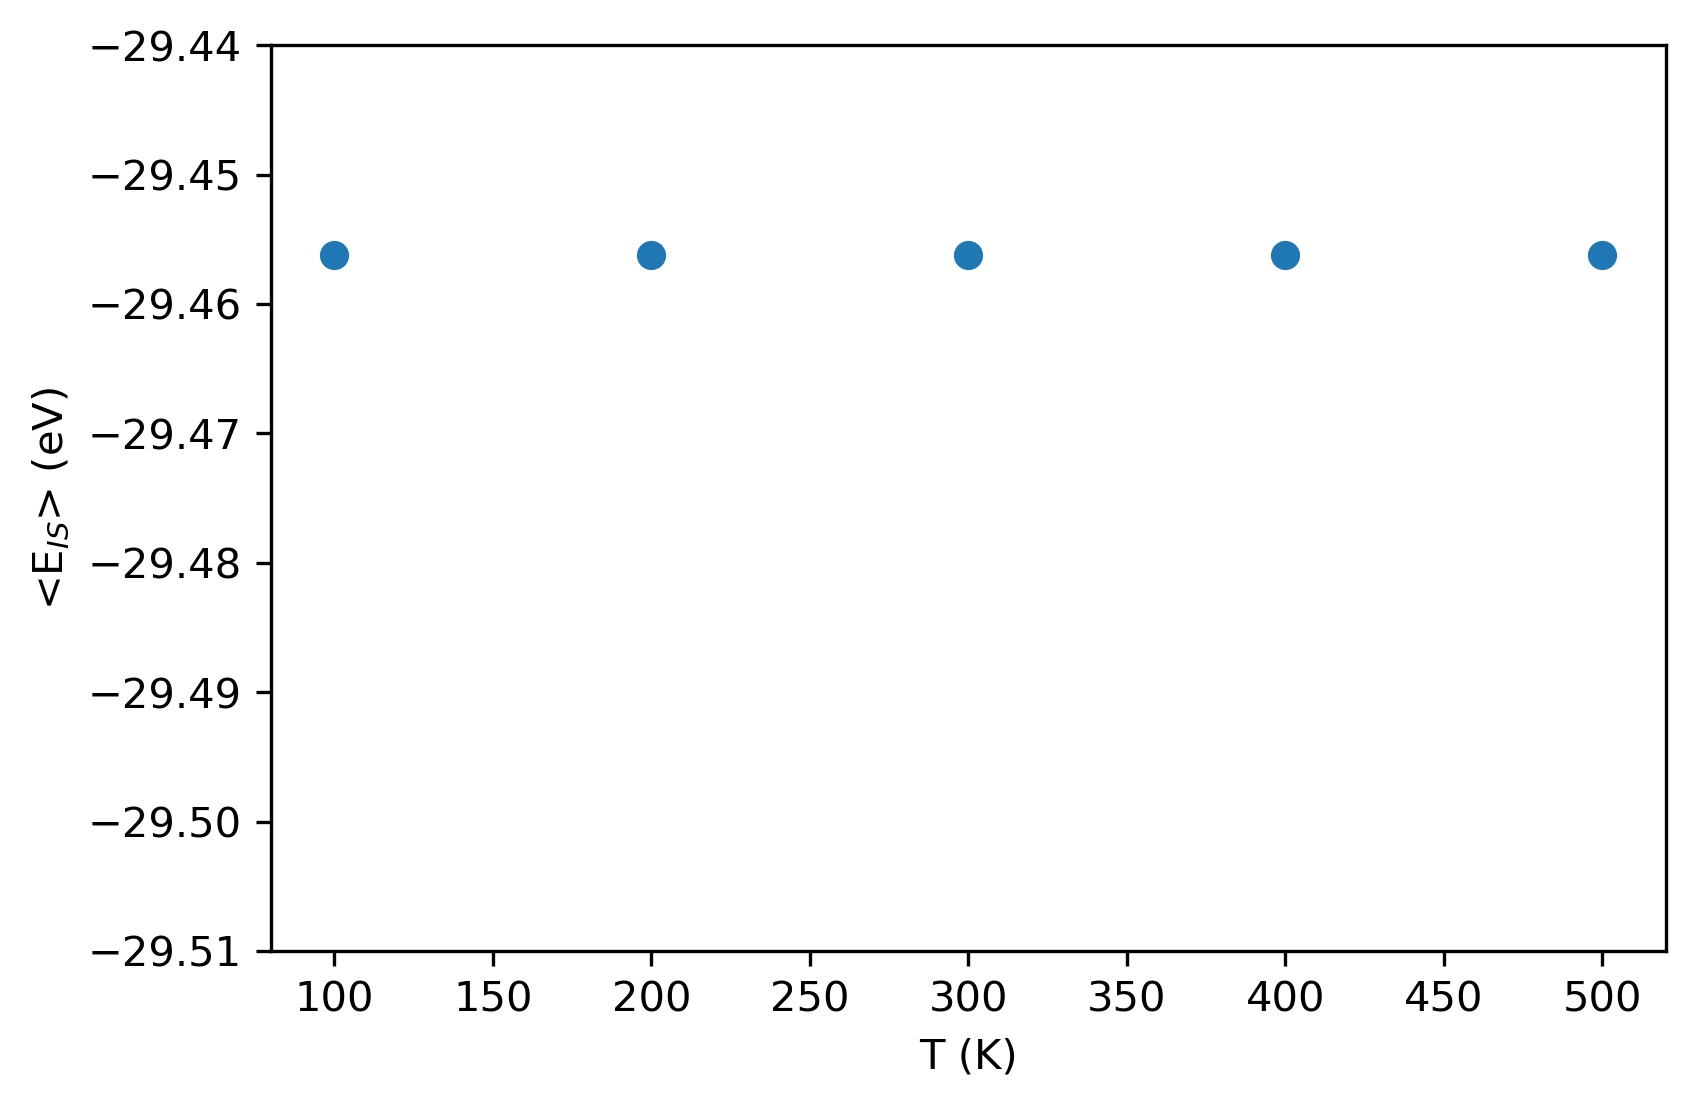

In [742]:


plt.ylim(-29.51,-29.44)
plt.xlabel('T (K)')
plt.ylabel('<E$_{IS}$> (eV)')

In [736]:
0.0001662*96.48*1000 #J/mol/K

16.034976

Text(0, 0.5, 'S$_{conf}$ (J/mol/K)')

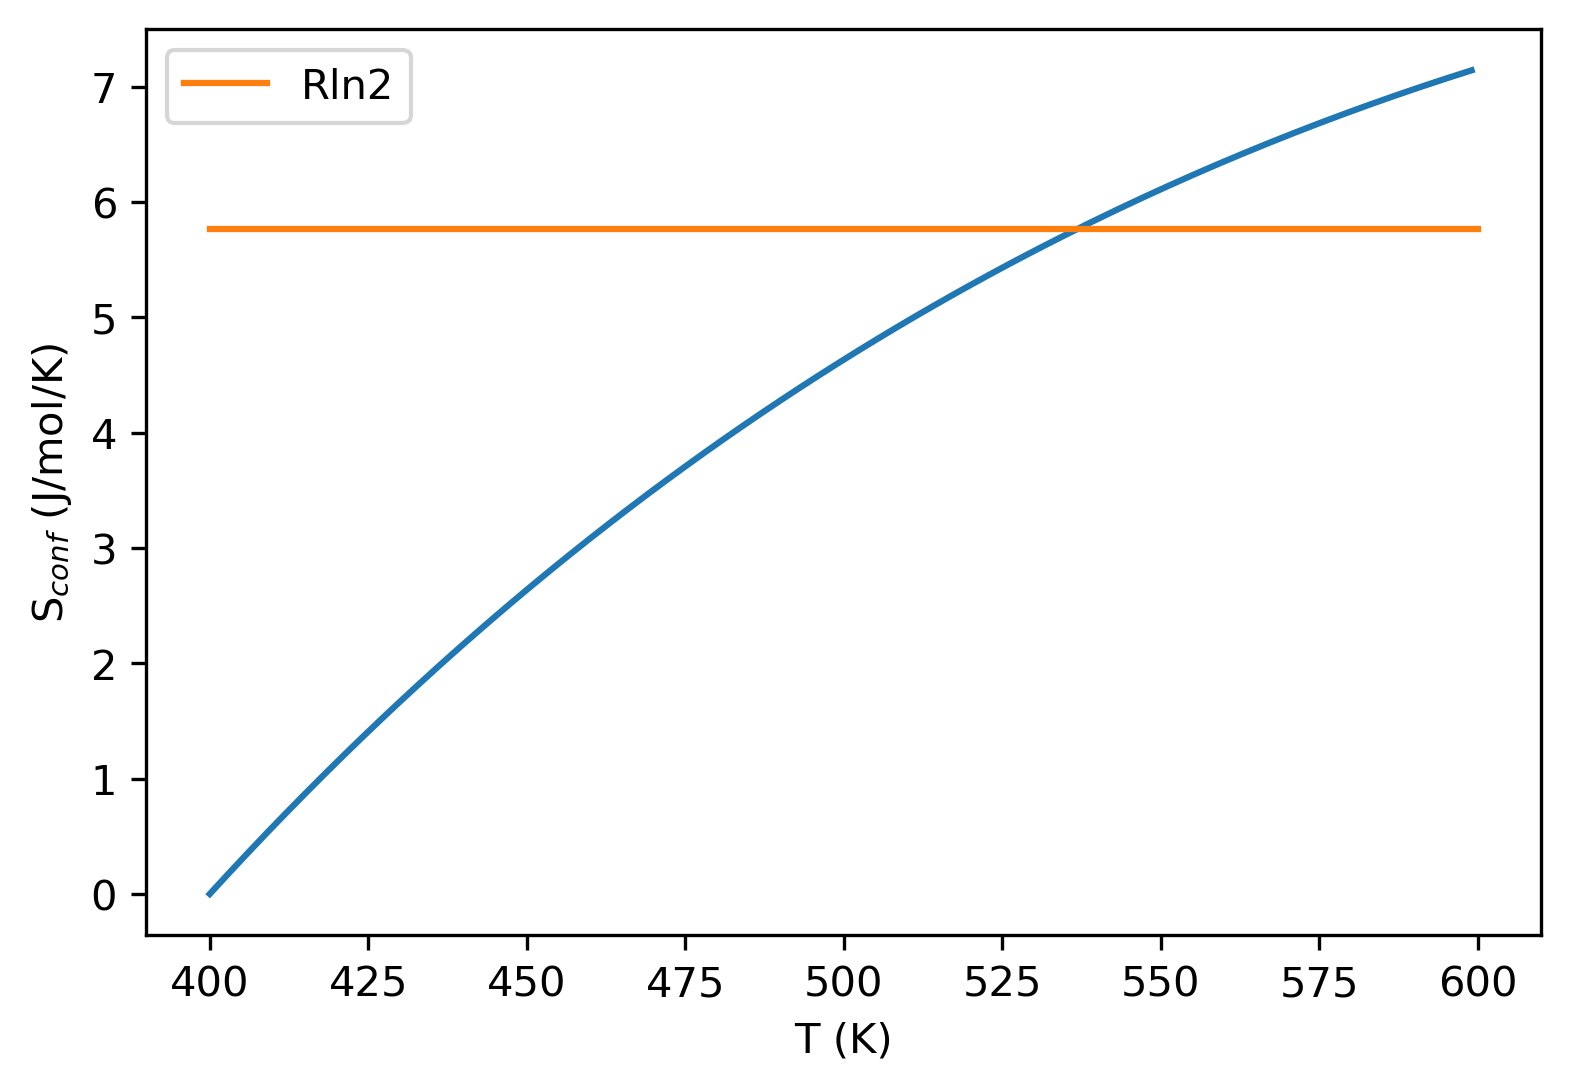

In [5]:
plt.figure(figsize=(6,4),dpi=300)
x=np.arange(400,600)
y=2*-3.571e-07*(x-400) + 0.0005353*np.log(x/400)
plt.plot(x,y*1000*96.48)
plt.plot([400,600], [8.314*np.log(2)]*2,label='Rln2')
plt.legend()
plt.xlabel('T (K)')
plt.ylabel('S$_{conf}$ (J/mol/K)')

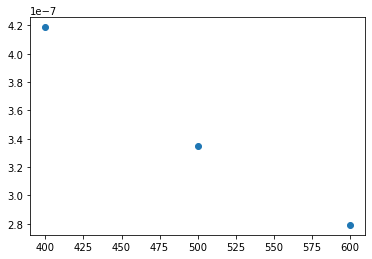

In [19]:
plt.plot(pe[1:,0],0.0001675/pe[1:,0],'o')

# III

In [781]:
path='/public/home/data_XZ/Free_energy_calculation_tutorial/quasi_harm_approx/NH4F/III_new'

In [782]:
vol=np.loadtxt('{}/volume.txt'.format(path))[:,1]
u=np.loadtxt('{}/potential.txt'.format(path))[:,1]

In [783]:
dire=np.loadtxt('{}/volume.txt'.format(path))[:,0]
npoints=len(vol)
Temp=np.arange(100,600,100)
isobar_III=np.zeros((npoints,len(Temp)), dtype=float)
Anharmonic_F=np.zeros((npoints,len(Temp)), dtype=float)
N=750/6
S_III=np.zeros((npoints,len(Temp)), dtype=float)
pressure=17000 #bar
for i in range(npoints):
    fnm='{}/disp-conf/200_{}/frequency.dat'.format(path,dire[i])
    data=np.loadtxt(fnm)
    for j in range(len(Temp)):
        isobar_III[i,j]=Gibbs_cl(N,Temp[j],data,pressure,vol[i],u[i])
        S_III[i,j]=S_qm(N,Temp[j],data)
    

Text(0.5, 1.0, 'phase III, p=17000 bar')

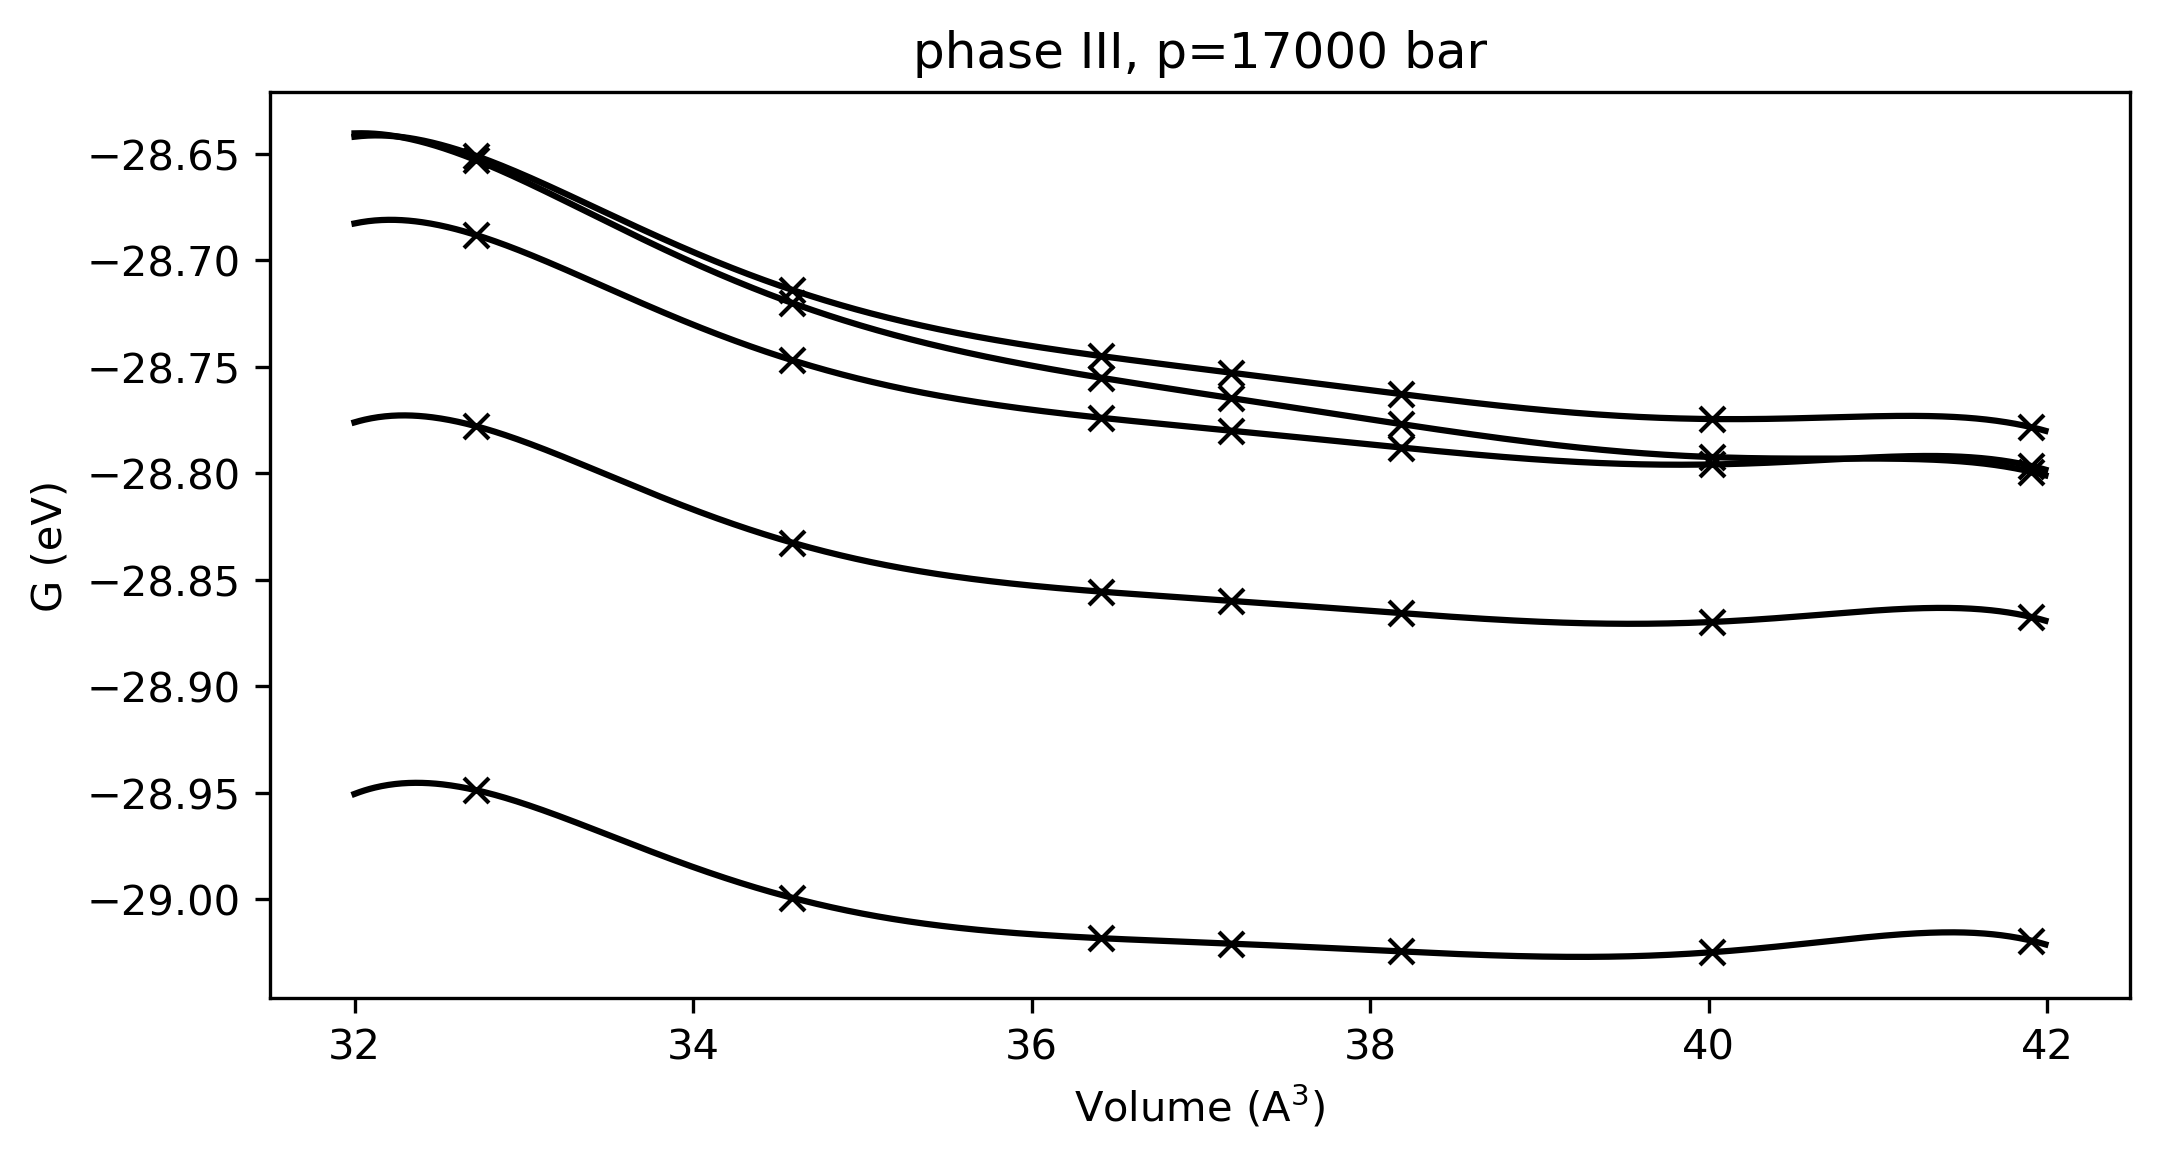

In [784]:
plt.figure(figsize=(8,4),dpi=300)
Gibbs_T_III=np.zeros((len(Temp),2),dtype=float)
for j in range(len(Temp)): #len(Temp)
    plt.plot(vol[:]/N,isobar_III[:,j],'kx')
    fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_III[:,j], 6))  
    plt.plot(np.arange(32,42,0.01),fitting(np.arange(32,42,0.01)),'-k')
    #print(np.roots(fitting.deriv()))
    #root_list=np.roots(fitting.deriv())
    #root=root_list[(root_list.real > 34) & (root_list.real < 41) & (root_list.imag==0)]
    #print(root)
    #plt.plot(root.real,fitting(root.real),'bv', ms=10)
    #Gibbs_T_III[j,0]=Temp[j]
    #Gibbs_T_III[j,1]=fitting(root.real)

plt.xlabel('Volume (A$^3$)')
plt.ylabel('G (eV)')
plt.title('phase III, p={} bar'.format(pressure))

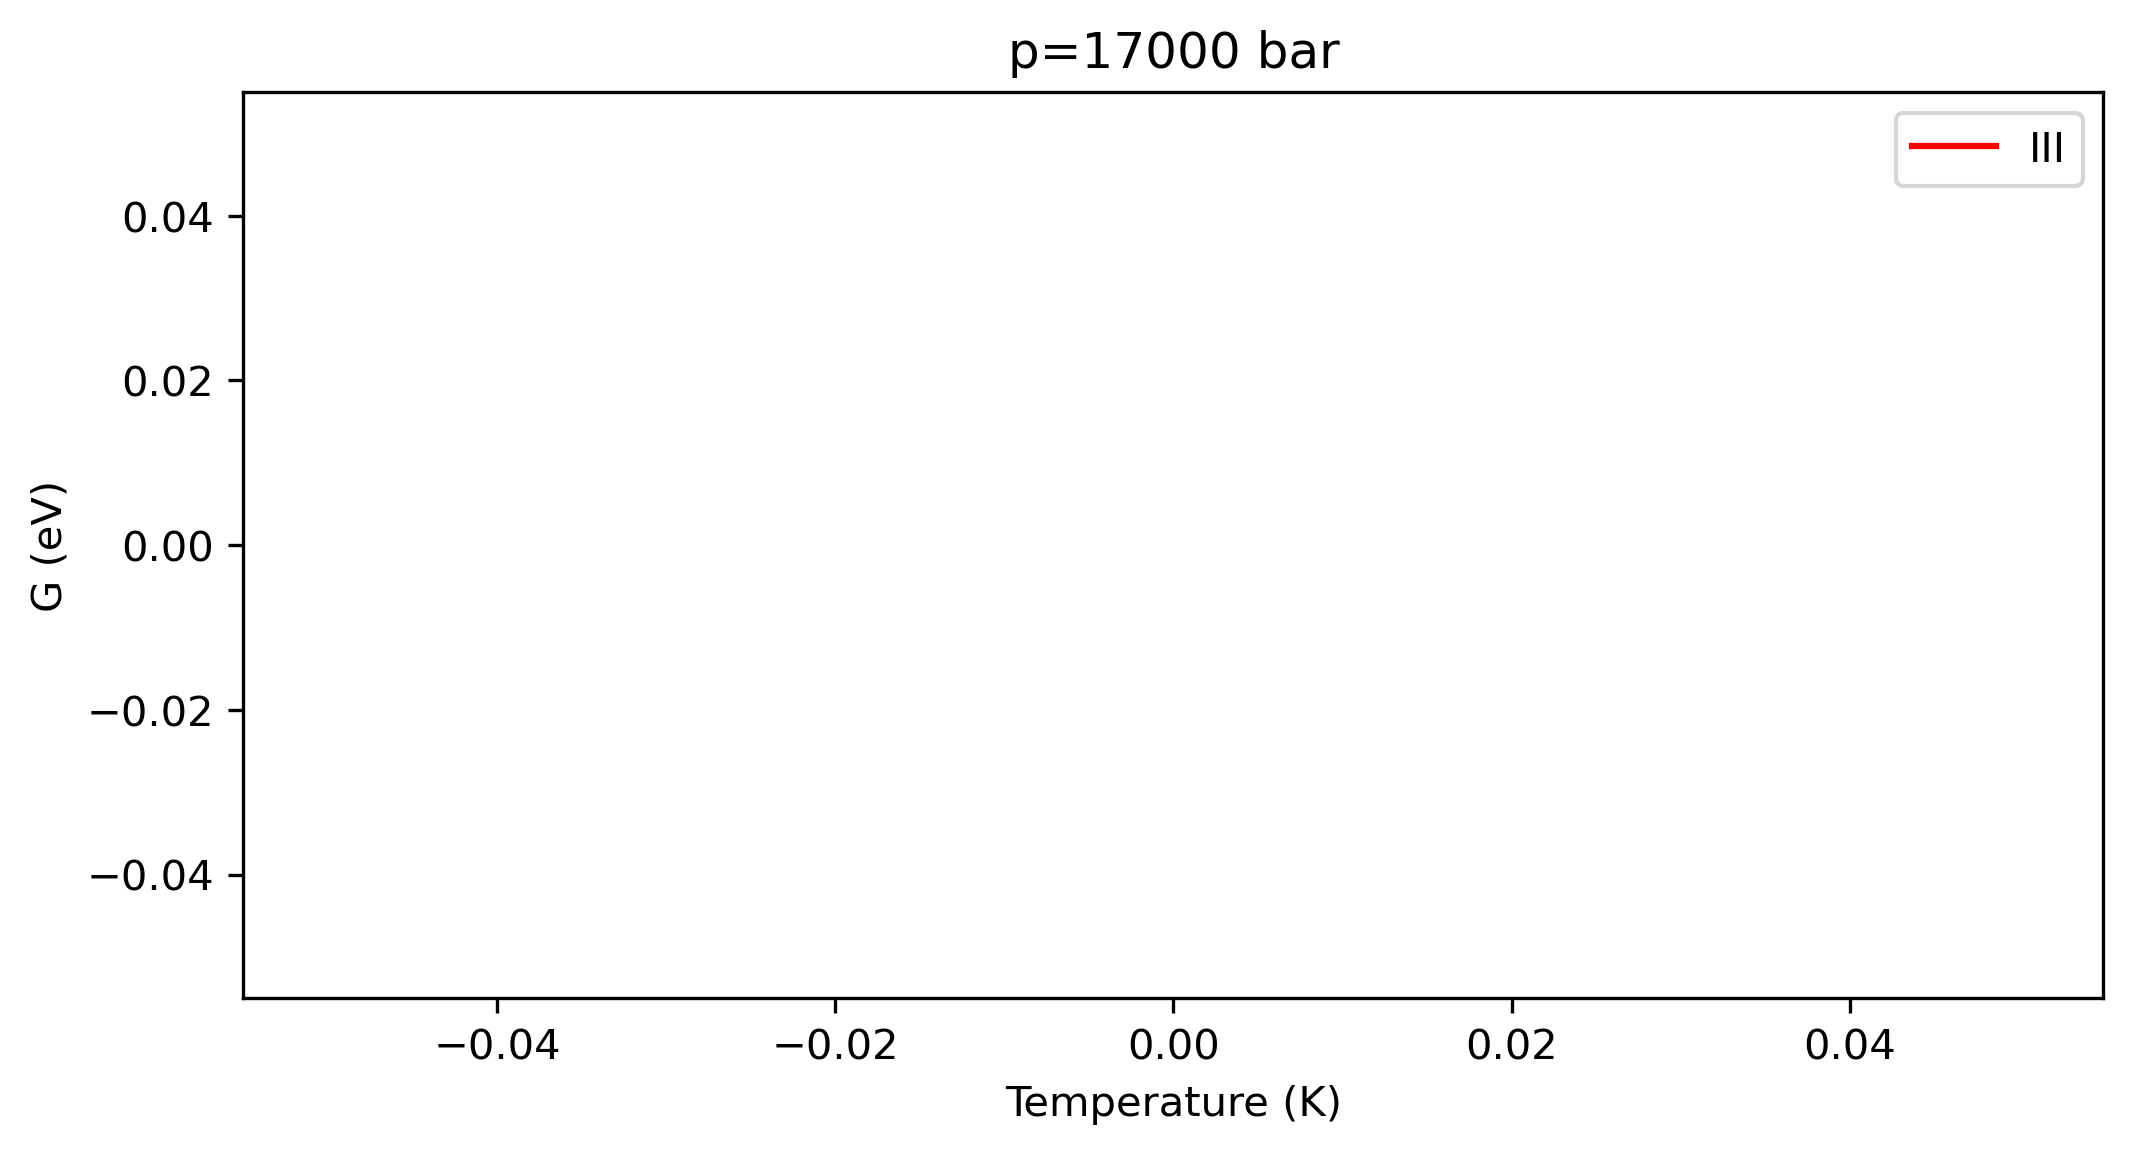

In [538]:
plt.figure(figsize=(8,4),dpi=300)
def TSc(T):
    return 8.314*T*np.log(2)/1000/96.48
plt.plot(Gibbs_T_III[:,0], Gibbs_T_III[:,1]-TSc(Gibbs_T_III[:,0]),'r-',label='III')
plt.xlabel('Temperature (K)')
plt.ylabel('G (eV)')
plt.title('p={} bar'.format(pressure))
plt.legend()
#plt.xlim(540,600)
#plt.ylim(-27.9,-27.80)

[-1.84893548e-07  5.50456824e-09 -3.45248839e-11  7.75247614e-14
 -5.74963429e-17]
[-2.58972996e-07  7.26400129e-09 -4.63762797e-11  1.08332650e-13
 -8.38485425e-17]
[-1.44924004e-07  5.44848387e-09 -3.79100985e-11  9.14198764e-14
 -7.12076125e-17]
[-6.78450992e-07  1.73780682e-08 -1.18941512e-10  2.93489459e-13
 -2.38131262e-16]
[ 3.30522244e-07 -2.59602269e-09  2.60327046e-12  6.37930272e-15
 -6.08533138e-18]
[-1.54599028e-07  6.55504890e-09 -4.86088013e-11  1.27906853e-13
 -1.08390425e-16]
[ 4.12299466e-07 -6.08832908e-09  3.11229101e-11 -5.88989483e-14
  3.94889093e-17]


Text(0.5, 0, 'Temperature (K)')

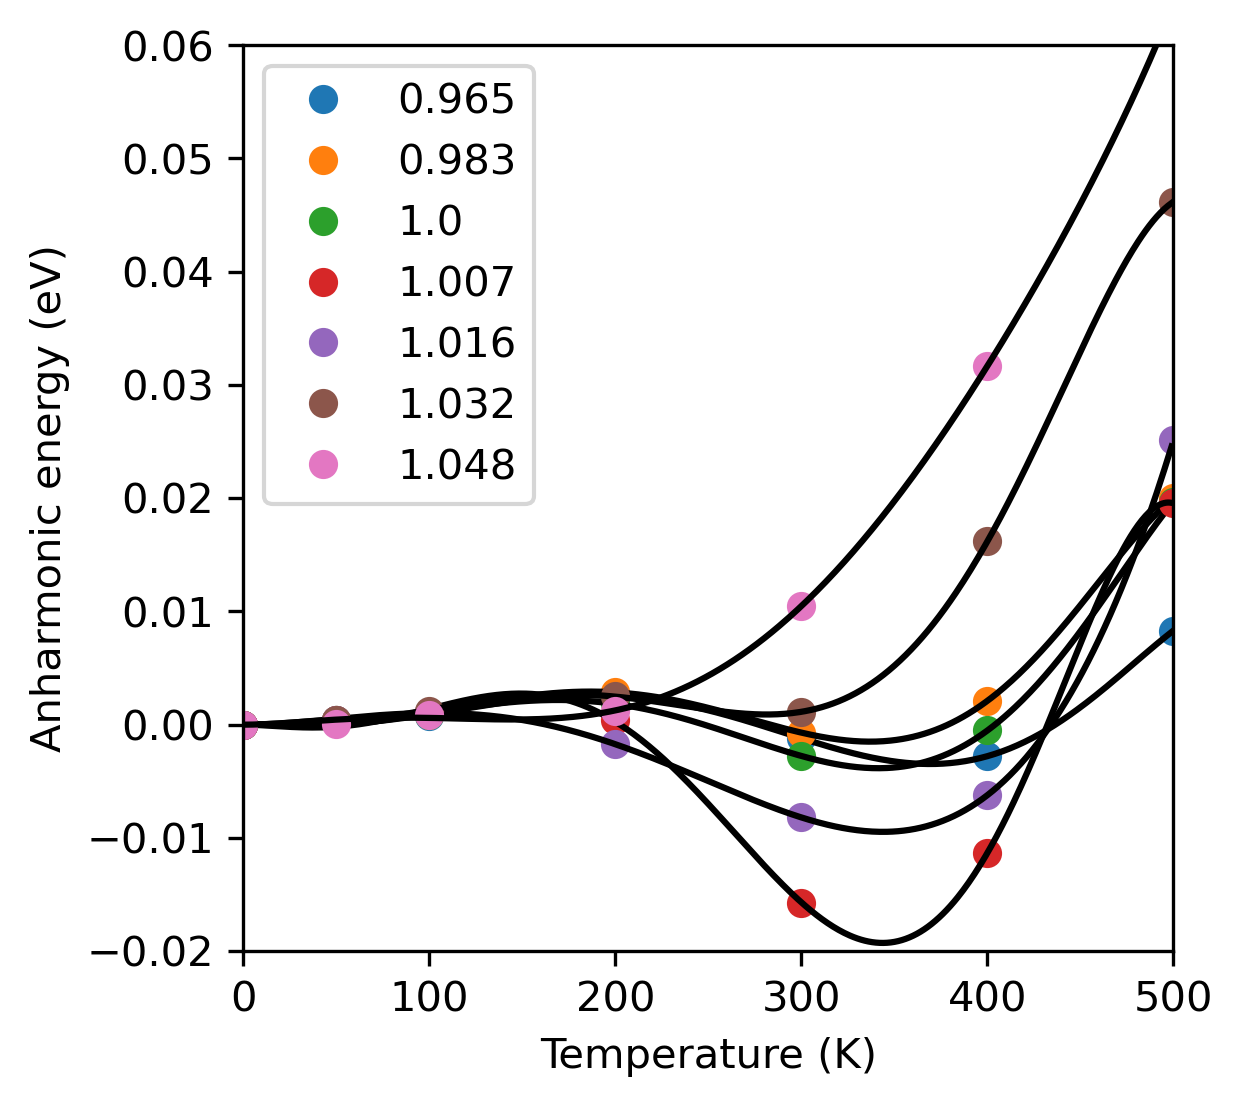

In [787]:

from scipy.optimize import curve_fit
def fitting_func(x, k2,k3,k4,k5,k6):
    return  k2*x**2 + k3*x**3 + k4*x**4 + k5*x**5 + k6*x**6
def F_anharm(x,k2,k3,k4,k5,k6):
    return -1*x*( k2*x + (k3/2)*x**2 + (k4/3)*x**3 + (k5/4)*x**4 + (k6/5)*x**5)


plt.figure(figsize=(4,4),dpi=300)
for i in range(npoints):
    data=np.loadtxt('{}/anharmonic/{}.dat'.format(path,dire[i]))
    T_=data[:7,0]
    Uh=(3*750*8.314*data[:7,0])/1000/96.48/2
    Uq=data[0,1]
    Ua=data[:7,1]-Uq-Uh
    plt.plot(T_,Ua/N/T_**0,'o',label='{}'.format(dire[i]))
    popt, pcov = curve_fit(fitting_func, T_, Ua/N, p0=[7.1e-05, 1.06e-05, -1.628e-08,3.806e-11,3.806e-11])  # p0 是初始猜测值
    k = popt[:]
    y_fit = fitting_func(np.arange(500), k[0],k[1],k[2],k[3],k[4])
    plt.plot(np.arange(500), y_fit/np.arange(500)**0, 'k-')
    Anharmonic_F[i,:]=F_anharm(Temp,k[0],k[1],k[2],k[3],k[4])
    print(k)

#plt.plot(data[:,0],(3*576*8.314*data[:,0])/1000/96.48/2,'--k')
    
plt.legend()
plt.xlim(0,500)
plt.ylim(-0.02,0.06)
plt.ylabel('Anharmonic energy (eV)')
plt.xlabel('Temperature (K)')

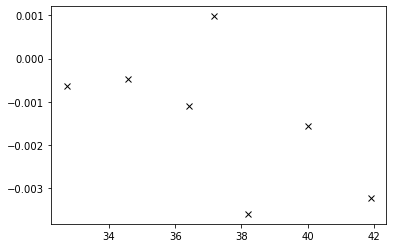

In [646]:
 plt.plot(vol[:]/N,Anharmonic_F[:,10],'kx')

Text(0.5, 1.0, 'phase III with anharmonic term, p=17000 GPa')

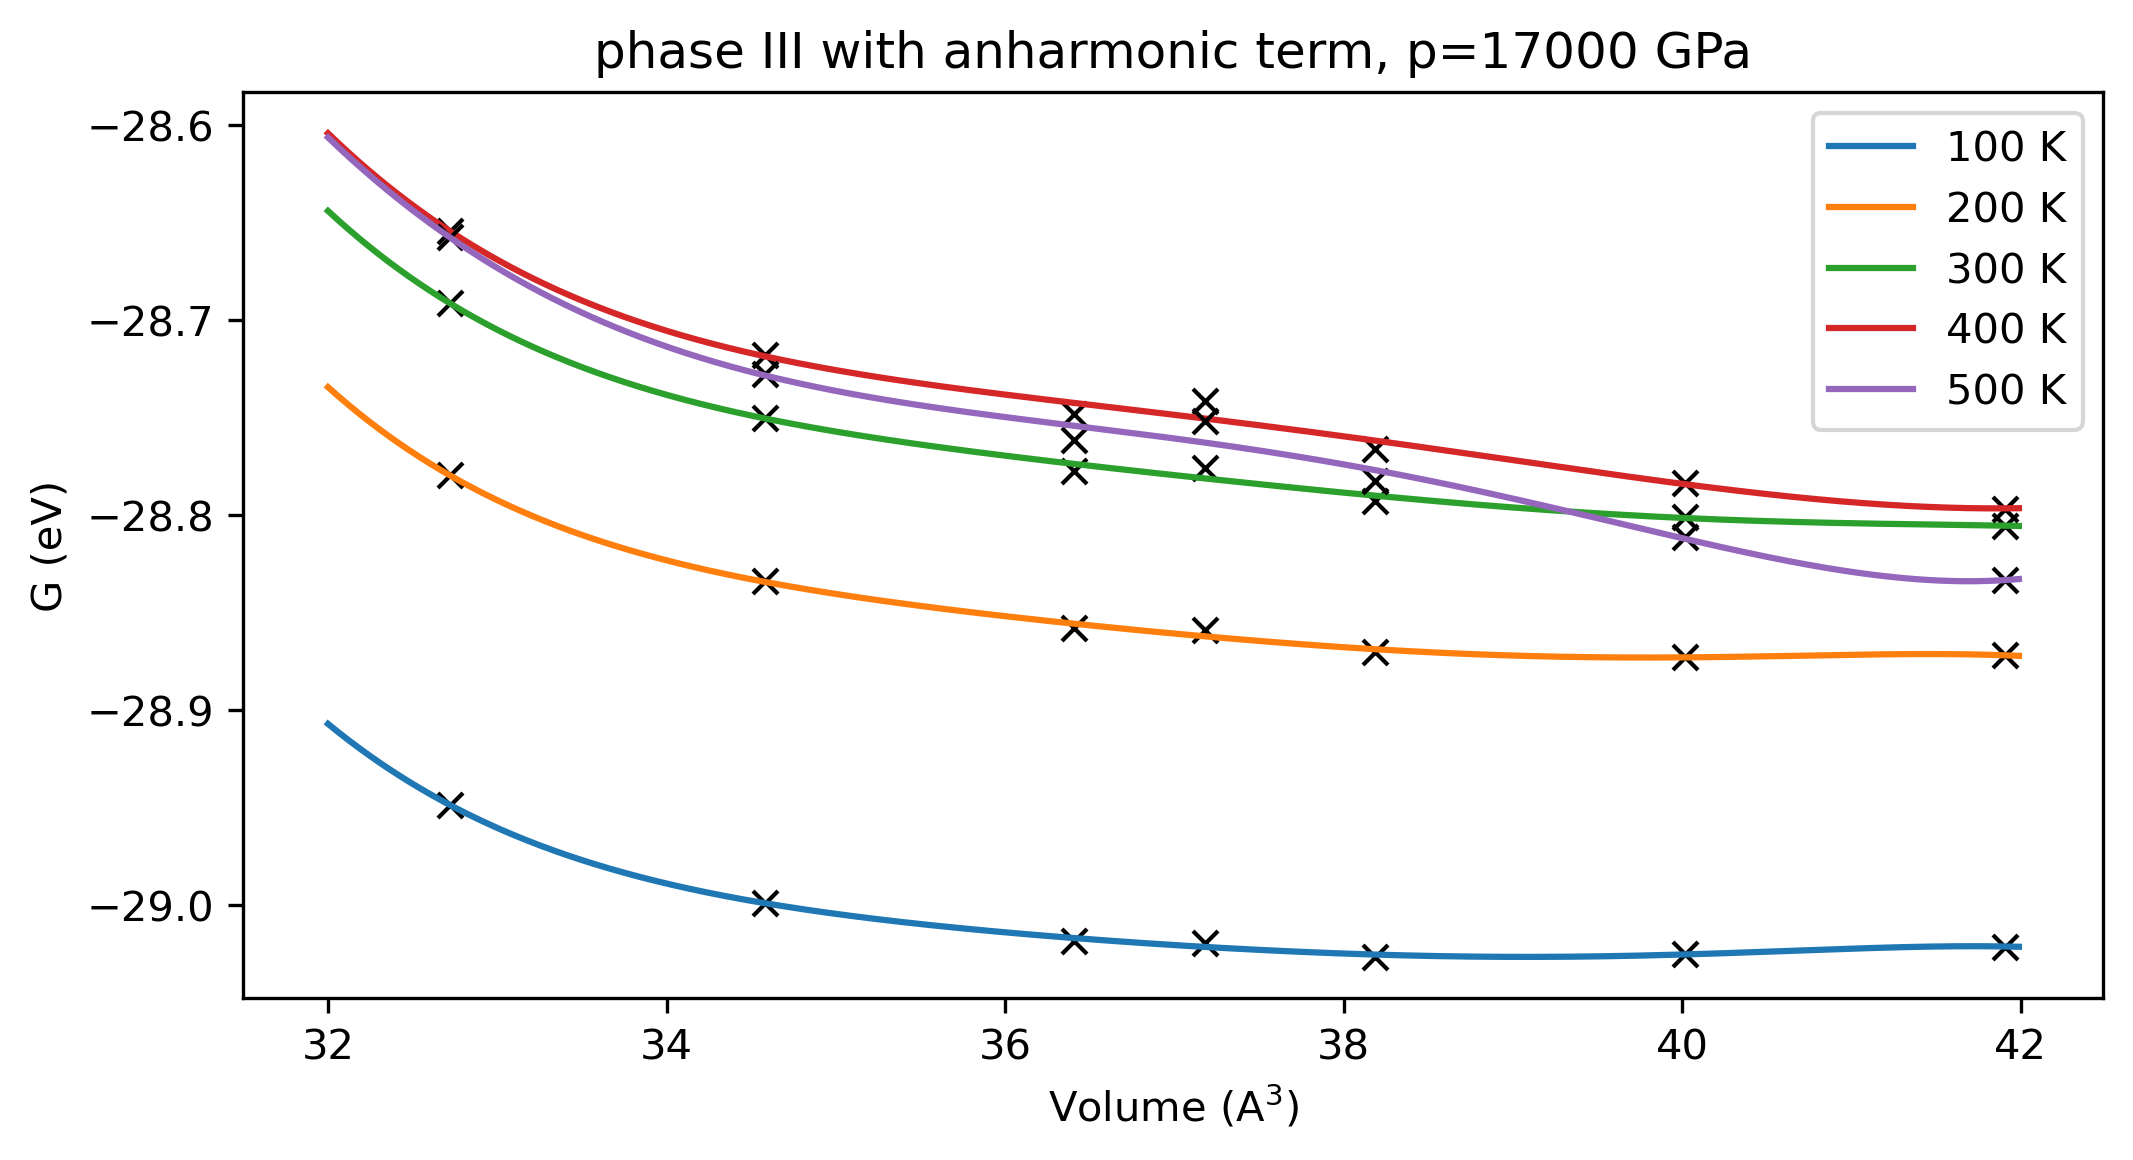

In [698]:
def TSc(T):
    return 8.314*T*np.log(2)/1000/96.48

plt.figure(figsize=(8,4),dpi=300)
Gibbs_T_III_anh=np.zeros((len(Temp),2),dtype=float)
for j in range(len(Temp)):
    plt.plot(vol[:]/N,isobar_III[:,j]+Anharmonic_F[:,j]-TSc(Temp[j]),'kx')
    fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_III[:,j]+Anharmonic_F[:,j]-TSc(Temp[j]), 5))  
    plt.plot(np.arange(32,42,0.01),fitting(np.arange(32,42,0.01)),'-',label='{} K'.format(Temp[j]))
    #root_list=np.roots(fitting.deriv())
    #root=root_list[(root_list.real > 34) & (root_list.real < 40) & (root_list.imag==0)][1]
    #print(root)
    #plt.plot(root.real,fitting(root.real),'bv', ms=10)
    #Gibbs_T_III_anh[j,0]=Temp[j]
    #Gibbs_T_III_anh[j,1]=fitting(root.real)
#print(50,fitting(42.90784787))
#Gibbs_T[0,0]=50
#Gibbs_T[0,1]=fitting(42.90784787)

plt.legend()
plt.xlabel('Volume (A$^3$)')
plt.ylabel('G (eV)')
plt.title('phase III with anharmonic term, p={} GPa'.format(pressure))
#plt.ylim(-28.7,-28.3)

In [310]:
Uq=-3674.44495297979
T_=np.array([0,50,100,200,300,400,500,600,700,800])
Uh=(3*750*8.314*T_)/1000/96.48/2
Ua=(np.array([-3674.44495297979,-3669.55, -3664.64, -3654.82, -3645.71, -3635.73, -3623.51, -3610.41,-3596.85, -3584.2]) -Uq-Uh)
print(Ua/T_**2, Uh)

[            nan  1.90819382e-05  1.10456711e-05  5.89901106e-06
 -3.87262029e-06 -3.93950593e-07  9.84988655e-06  1.62999316e-05
  1.98642431e-05  1.98265357e-05] [ 0.          4.84724813  9.69449627 19.38899254 29.08348881 38.77798507
 48.47248134 58.16697761 67.86147388 77.55597015]


<ipython-input-310-abbec8d1bccc>:5: RuntimeWarning: invalid value encountered in true_divide
  print(Ua/T_**2, Uh)


In [344]:
Uq2=-3672.17220454857
T_=np.array([0,50,100,200,300,400,500,600,700,800])
Uh2=(3*750*8.314*T_)/1000/96.48/2
Ua2=(np.array([-3672.17220454857,-3667.43,-3662.57,-3652.74,-3641.96,-3629.89,-3616.45,-3603.23,-3590.77,-3578.57]) -Uq2-Uh2)

Text(0.5, 0, 'T (K)')

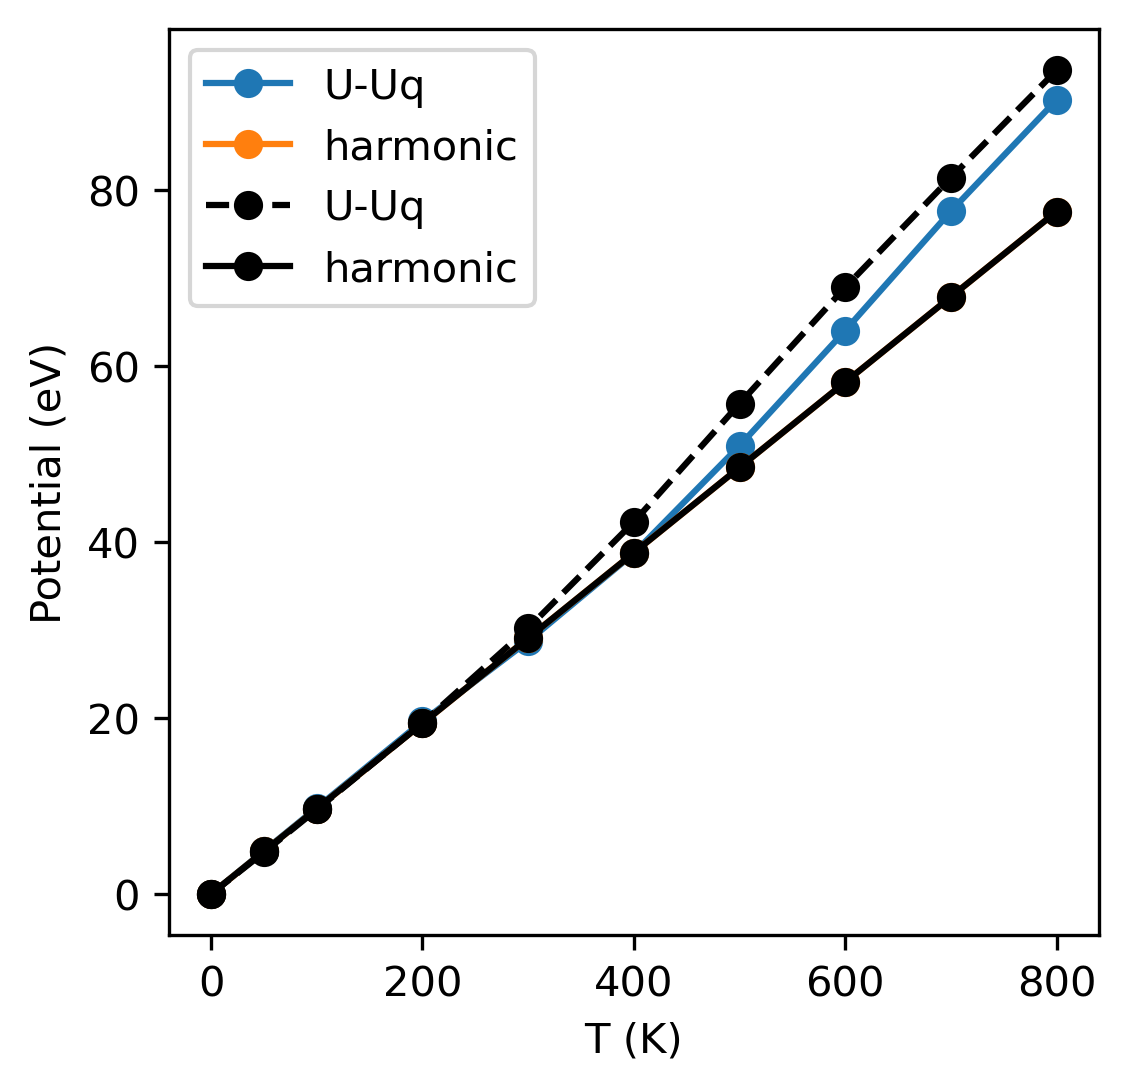

In [346]:
plt.figure(figsize=(4,4),dpi=300)
plt.plot(T_, Ua+Uh,'-o',label='U-Uq')
plt.plot(T_, Uh,'-o',label='harmonic')

plt.plot(T_, Ua2+Uh2,'--ko',label='U-Uq')
plt.plot(T_, Uh2,'-ko',label='harmonic')
plt.legend()
plt.ylabel('Potential (eV)')
plt.xlabel('T (K)')

[ 1.12446288e-06  1.08165665e-07 -1.64853845e-10  3.93024710e-13]


Text(0.5, 0, 'T')

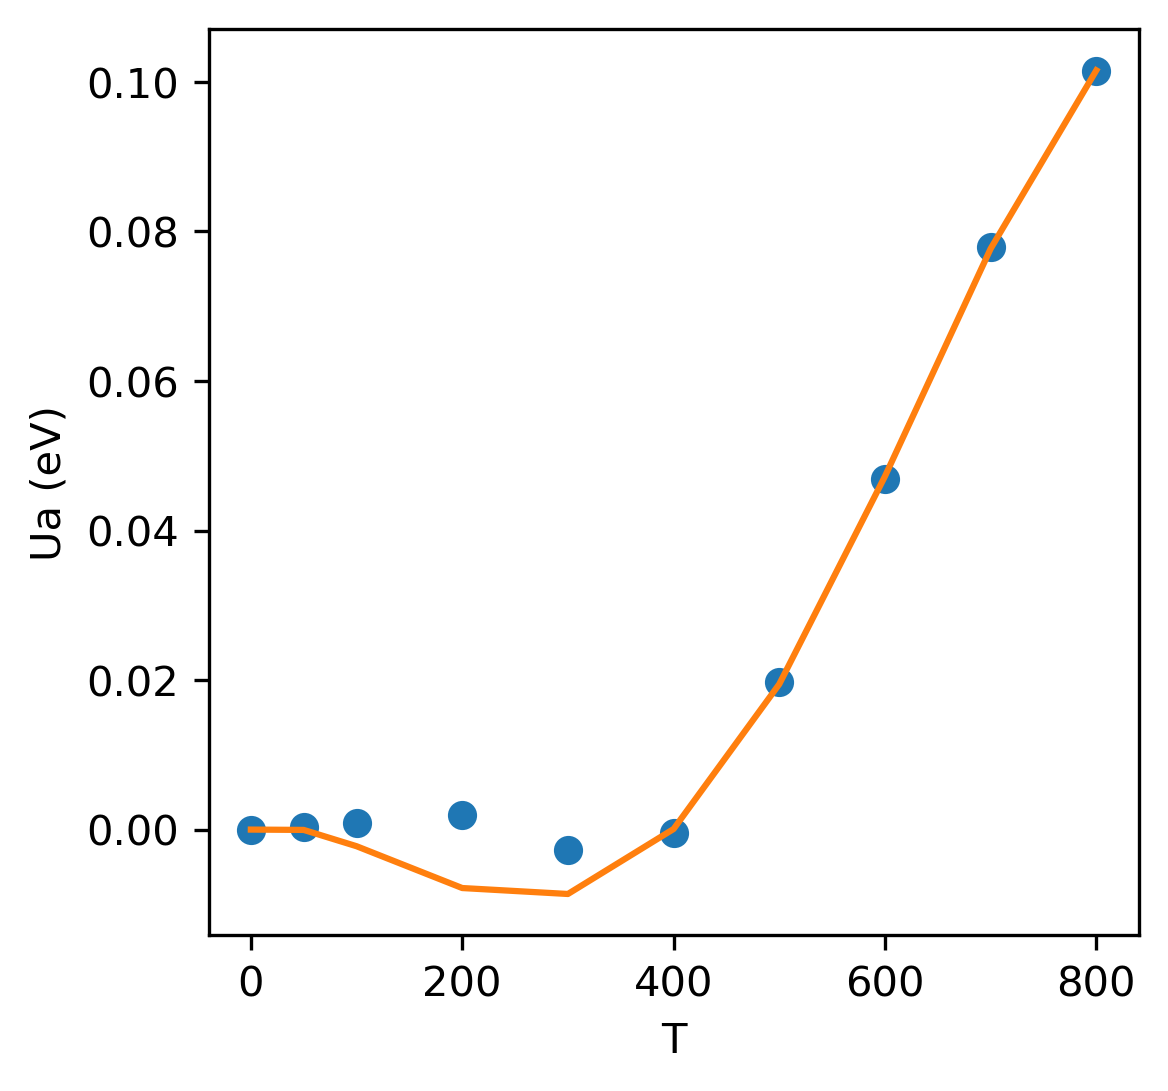

In [339]:
plt.figure(figsize=(4,4),dpi=300)
plt.plot(T_, Ua/N,'o')
from scipy.optimize import curve_fit
def fitting_func(x, k1,k2,k3,k4):
    return k1*x + k2*x**2 + k3*x**3 + k4*x**4

popt, pcov = curve_fit(fitting_func, np.array([400,500,600,700,800]), np.array([0,0.01969977,0.0469438,0.07786783,  0.10151186]), p0=[7.1e-05, 1.06e-05, -1.628e-10,3.806e-13])  # p0 是初始猜测值
k_III = popt[:]  # 提取斜率 k
y_fit = linear_func(T_, k_III[0],k_III[1],k_III[2],k_III[3])
plt.plot(T_, y_fit, '-')
print(k)
def F_anharm(x,k1,k2,k3,k4):
    return -1*x*(k1*np.log(x) + k2*x + (k3/2)*x**2 + (k4/3)*x**3)

plt.ylabel('Ua (eV)')
plt.xlabel('T')

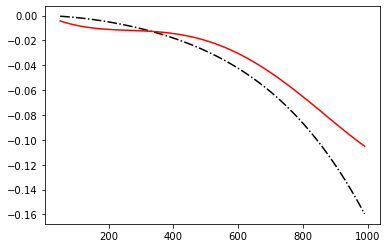

In [340]:
plt.plot(Gibbs_T_II[:,0], F_anharm(Gibbs_T_II[:,0],k[0],k[1],k[2],k[3]),'k-.',label='II:anharm')
plt.plot(Gibbs_T_III[:,0],F_anharm(Gibbs_T_III[:,0],k_III[0],k_III[1],k_III[2],k_III[3]),'r-',label='III:anharm')

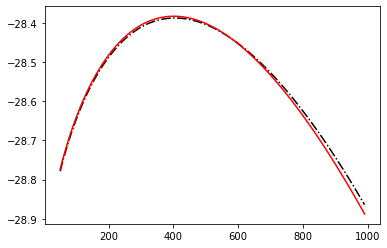

In [341]:
plt.plot(Gibbs_T_II[:,0], Gibbs_T_II[:,1],'k-.',label='II:harm')
plt.plot(Gibbs_T_III[:,0],Gibbs_T_III[:,1]-TSc(Gibbs_T_III[:,0]),'r-',label='III:harm')

In [342]:
Gibbs_T_III[35,0]

400.0

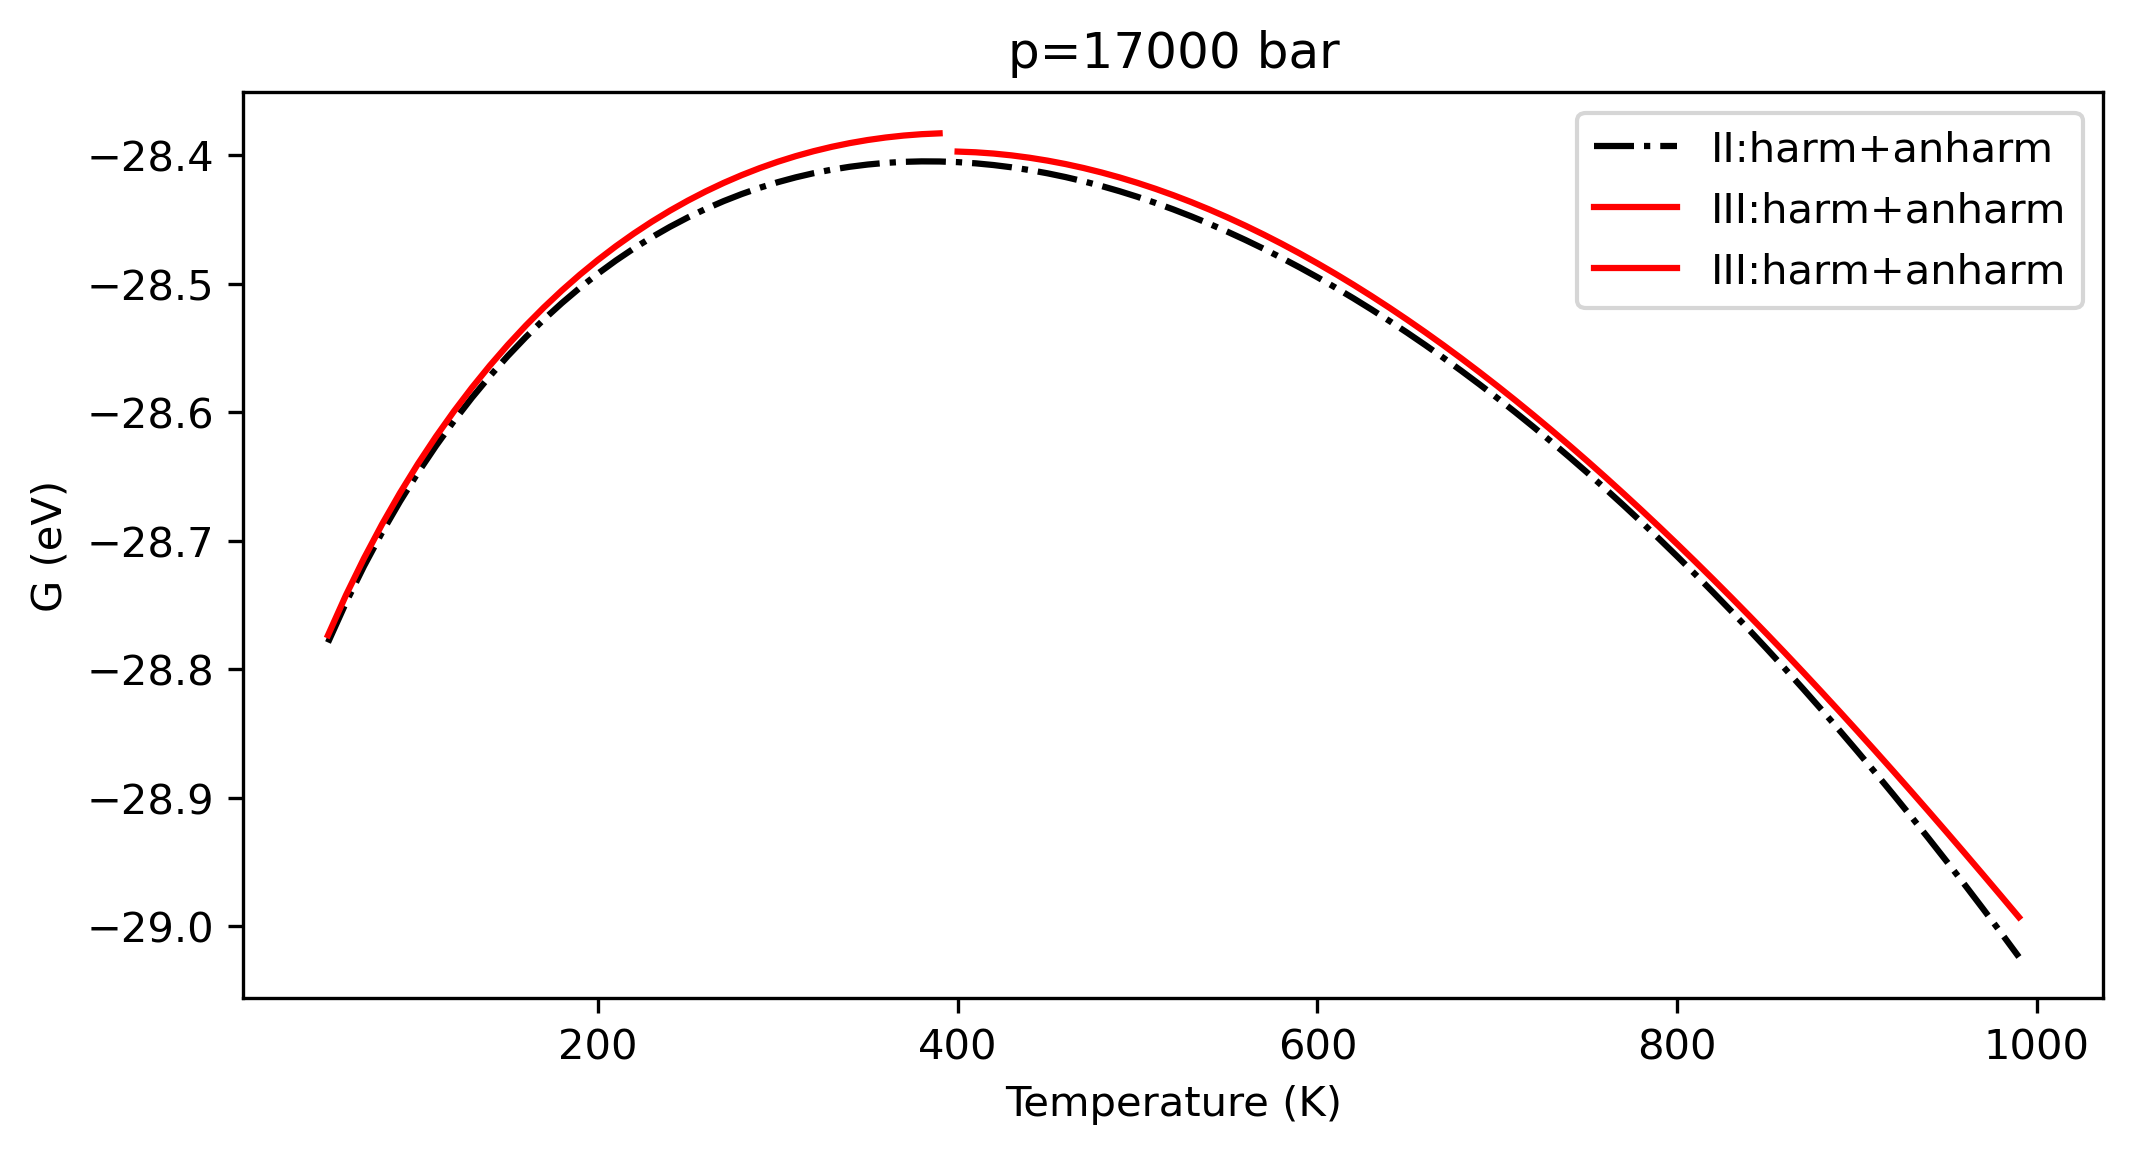

In [343]:
plt.figure(figsize=(8,4),dpi=300)
def TSc(T):
    return 8.314*T*np.log(2)/1000/96.48
plt.plot(Gibbs_T_II[:,0], Gibbs_T_II[:,1]+F_anharm(Gibbs_T_II[:,0],k[0],k[1],k[2],k[3]),'k-.',label='II:harm+anharm')
plt.plot(Gibbs_T_III[:35,0], Gibbs_T_III[:35,1]-TSc(Gibbs_T_III[:35,0]),'r-',label='III:harm+anharm')
plt.plot(Gibbs_T_III[35:,0], Gibbs_T_III[35:,1]-TSc(Gibbs_T_III[35:,0])+F_anharm(Gibbs_T_III[35:,0],k_III[0],k_III[1],k_III[2],k_III[3]),'r-',label='III:harm+anharm')
plt.xlabel('Temperature (K)')
plt.ylabel('G (eV)')
plt.title('p={} bar'.format(pressure))
plt.legend()
#plt.xlim(0,100)
#plt.ylim(-29.0,-28.80)

In [72]:


isobar_50K=np.zeros((9,1),dtype=float)
isobar_100K=np.zeros((9,1),dtype=float)
isobar_150K=np.zeros((9,1),dtype=float)
isobar_200K=np.zeros((9,1),dtype=float)
isobar_250K=np.zeros((9,1),dtype=float)

N=750/6
pres=np.loadtxt('{}/volume.txt'.format(path))[:,0]
for i in range(9):
    fnm='{}/disp-conf/200_{}/frequency.dat'.format(path,pres[i])
    data=np.loadtxt(fnm)
    isobar_100K[i]=Gibbs(N,100,data,2000,vol[i],u[i])
    isobar_50K[i]=Gibbs(N,50,data,  2000,vol[i],u[i])
    isobar_150K[i]=Gibbs(N,150,data,2000,vol[i],u[i])
    isobar_200K[i]=Gibbs(N,200,data,2000,vol[i],u[i])
    isobar_250K[i]=Gibbs(N,250,data,2000,vol[i],u[i])

[-129.03250452+0.j           44.62554243+0.j
   41.6308433 +0.j           36.18170025+3.92121785j
   36.18170025-3.92121785j]


(32.0, 46.0)

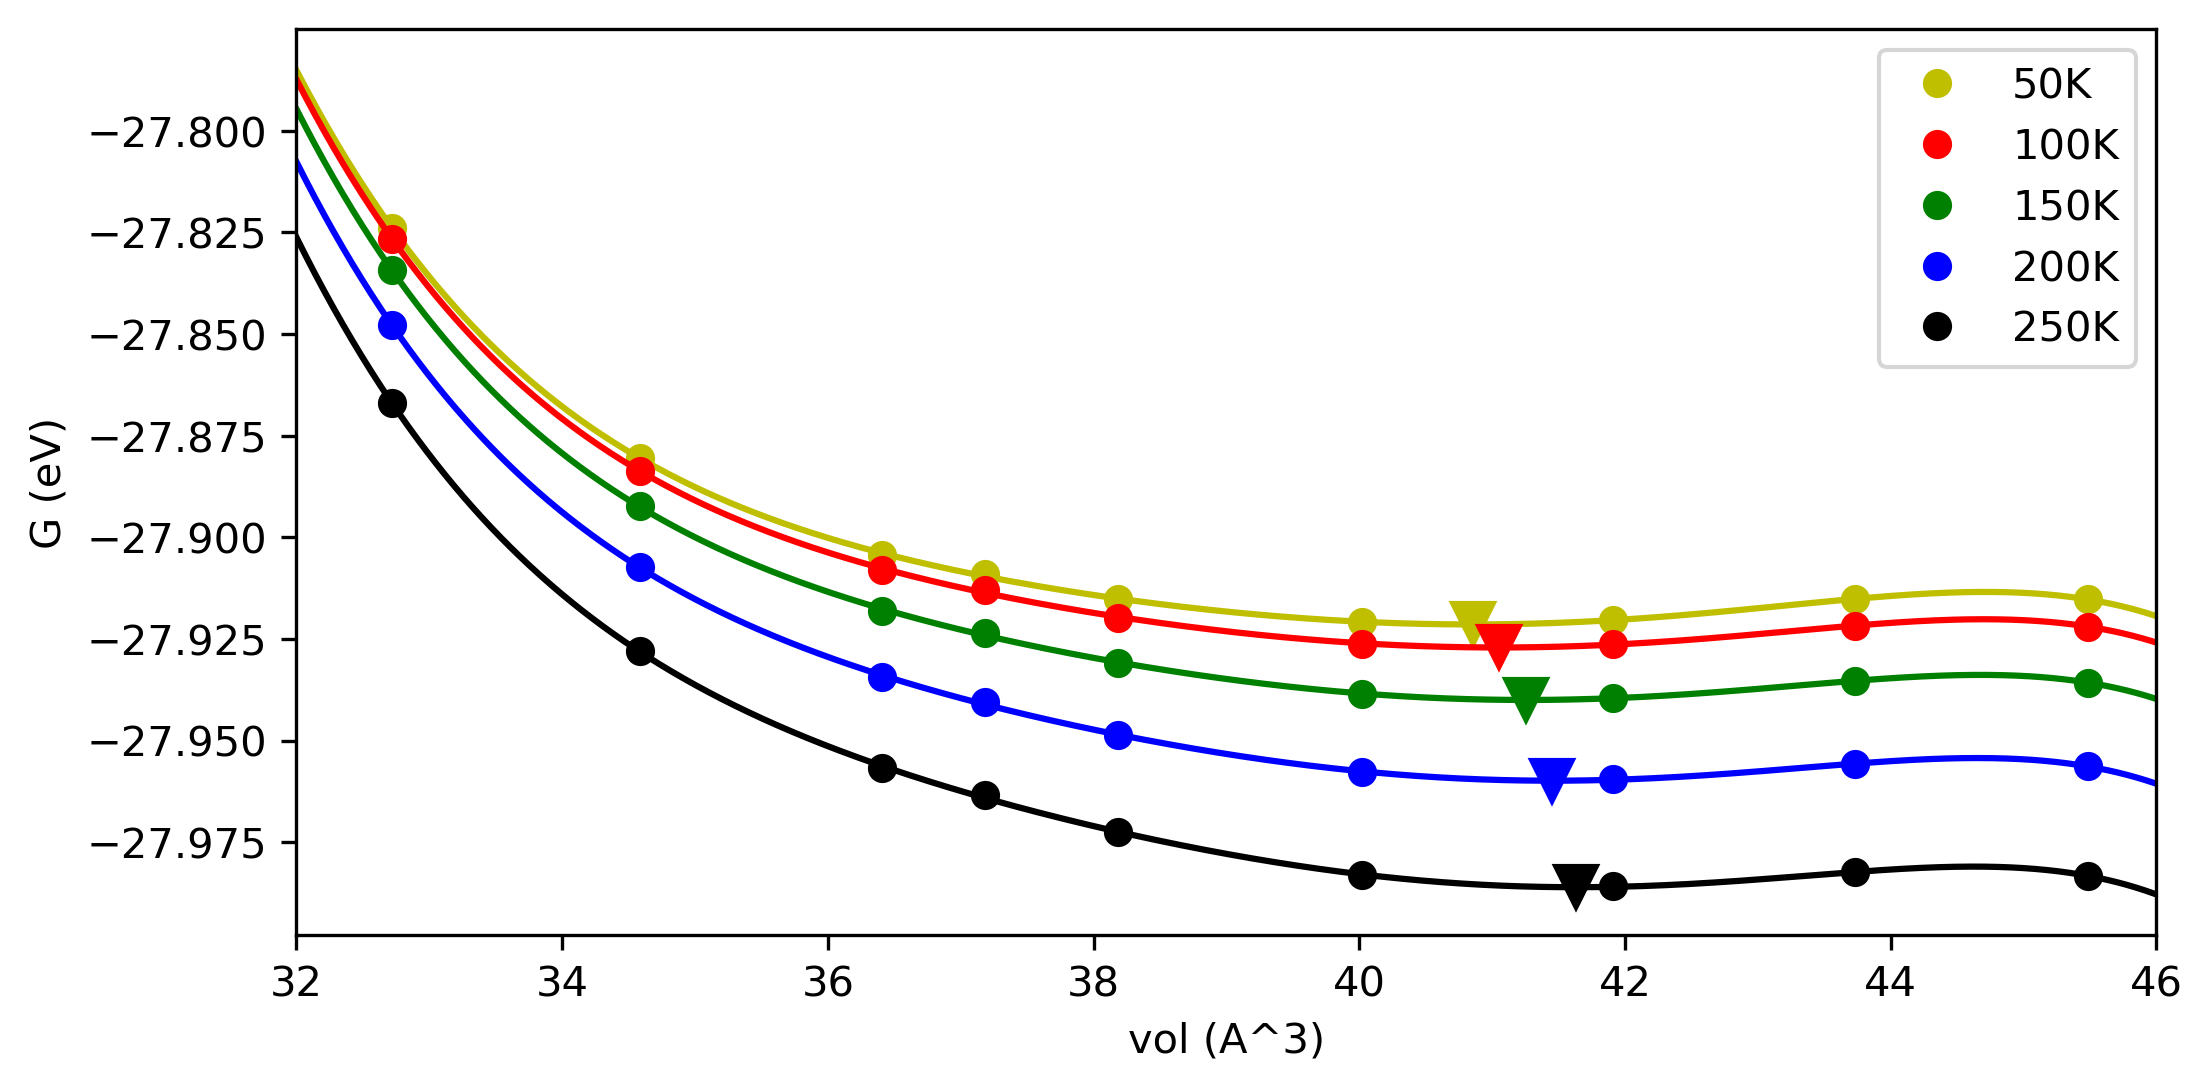

In [91]:
Gibbs_T_III=np.zeros((5,2),dtype=float)
plt.figure(figsize=(8,4),dpi=300)
plt.plot(vol[:]/N,isobar_50K[:],'yo',label='50K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_50K[:,0], 6))  
plt.plot(np.arange(32,46,0.01),fitting(np.arange(32,46,0.01)),'-y')
plt.plot(40.85303268,fitting(40.85303268),'yv', ms=10)
Gibbs_T_III[0,0]=50
Gibbs_T_III[0,1]=fitting(40.85303268)

plt.plot(vol[:]/N,isobar_100K[:],'ro',label='100K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_100K[:,0], 6))  
plt.plot(np.arange(32,46,0.01),fitting(np.arange(32,46,0.01)),'-r')
plt.plot(41.05117346,fitting(41.05117346),'rv', ms=10)
Gibbs_T_III[1,0]=100
Gibbs_T_III[1,1]=fitting(41.05117346)
##
plt.plot(vol[:]/N,isobar_150K[:],'go',label='150K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_150K[:,0], 6))  
plt.plot(np.arange(32,46,0.01),fitting(np.arange(32,46,0.01)),'-g')
plt.plot(41.25764173,fitting(41.25764173),'gv', ms=10)
Gibbs_T_III[2,0]=150
Gibbs_T_III[2,1]=fitting(41.25764173)
#
plt.plot(vol[:]/N,isobar_200K[:],'bo',label='200K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_200K[:,0], 6))  
plt.plot(np.arange(32,46,0.01),fitting(np.arange(32,46,0.01)),'-b')
plt.plot(41.45087576,fitting(41.45087576),'bv', ms=10)
Gibbs_T_III[3,0]=200
Gibbs_T_III[3,1]=fitting(41.45087576)
##
plt.plot(vol[:]/N,isobar_250K[:],'ko',label='250K')
fitting= np.poly1d(np.polyfit(vol[:]/N, isobar_250K[:,0], 6))  
plt.plot(np.arange(32,46,0.01),fitting(np.arange(32,46,0.01)),'-k')
print(np.roots(fitting.deriv()))
plt.plot(41.6308433,fitting(41.6308433),'kv', ms=10)
Gibbs_T_III[4,0]=250
Gibbs_T_III[4,1]=fitting(41.6308433)
#
plt.xlabel('vol (A^3)')
plt.ylabel('G (eV)')
plt.legend()
plt.xlim(32,46)

Text(0.5, 1.0, 'p=2000 bar')

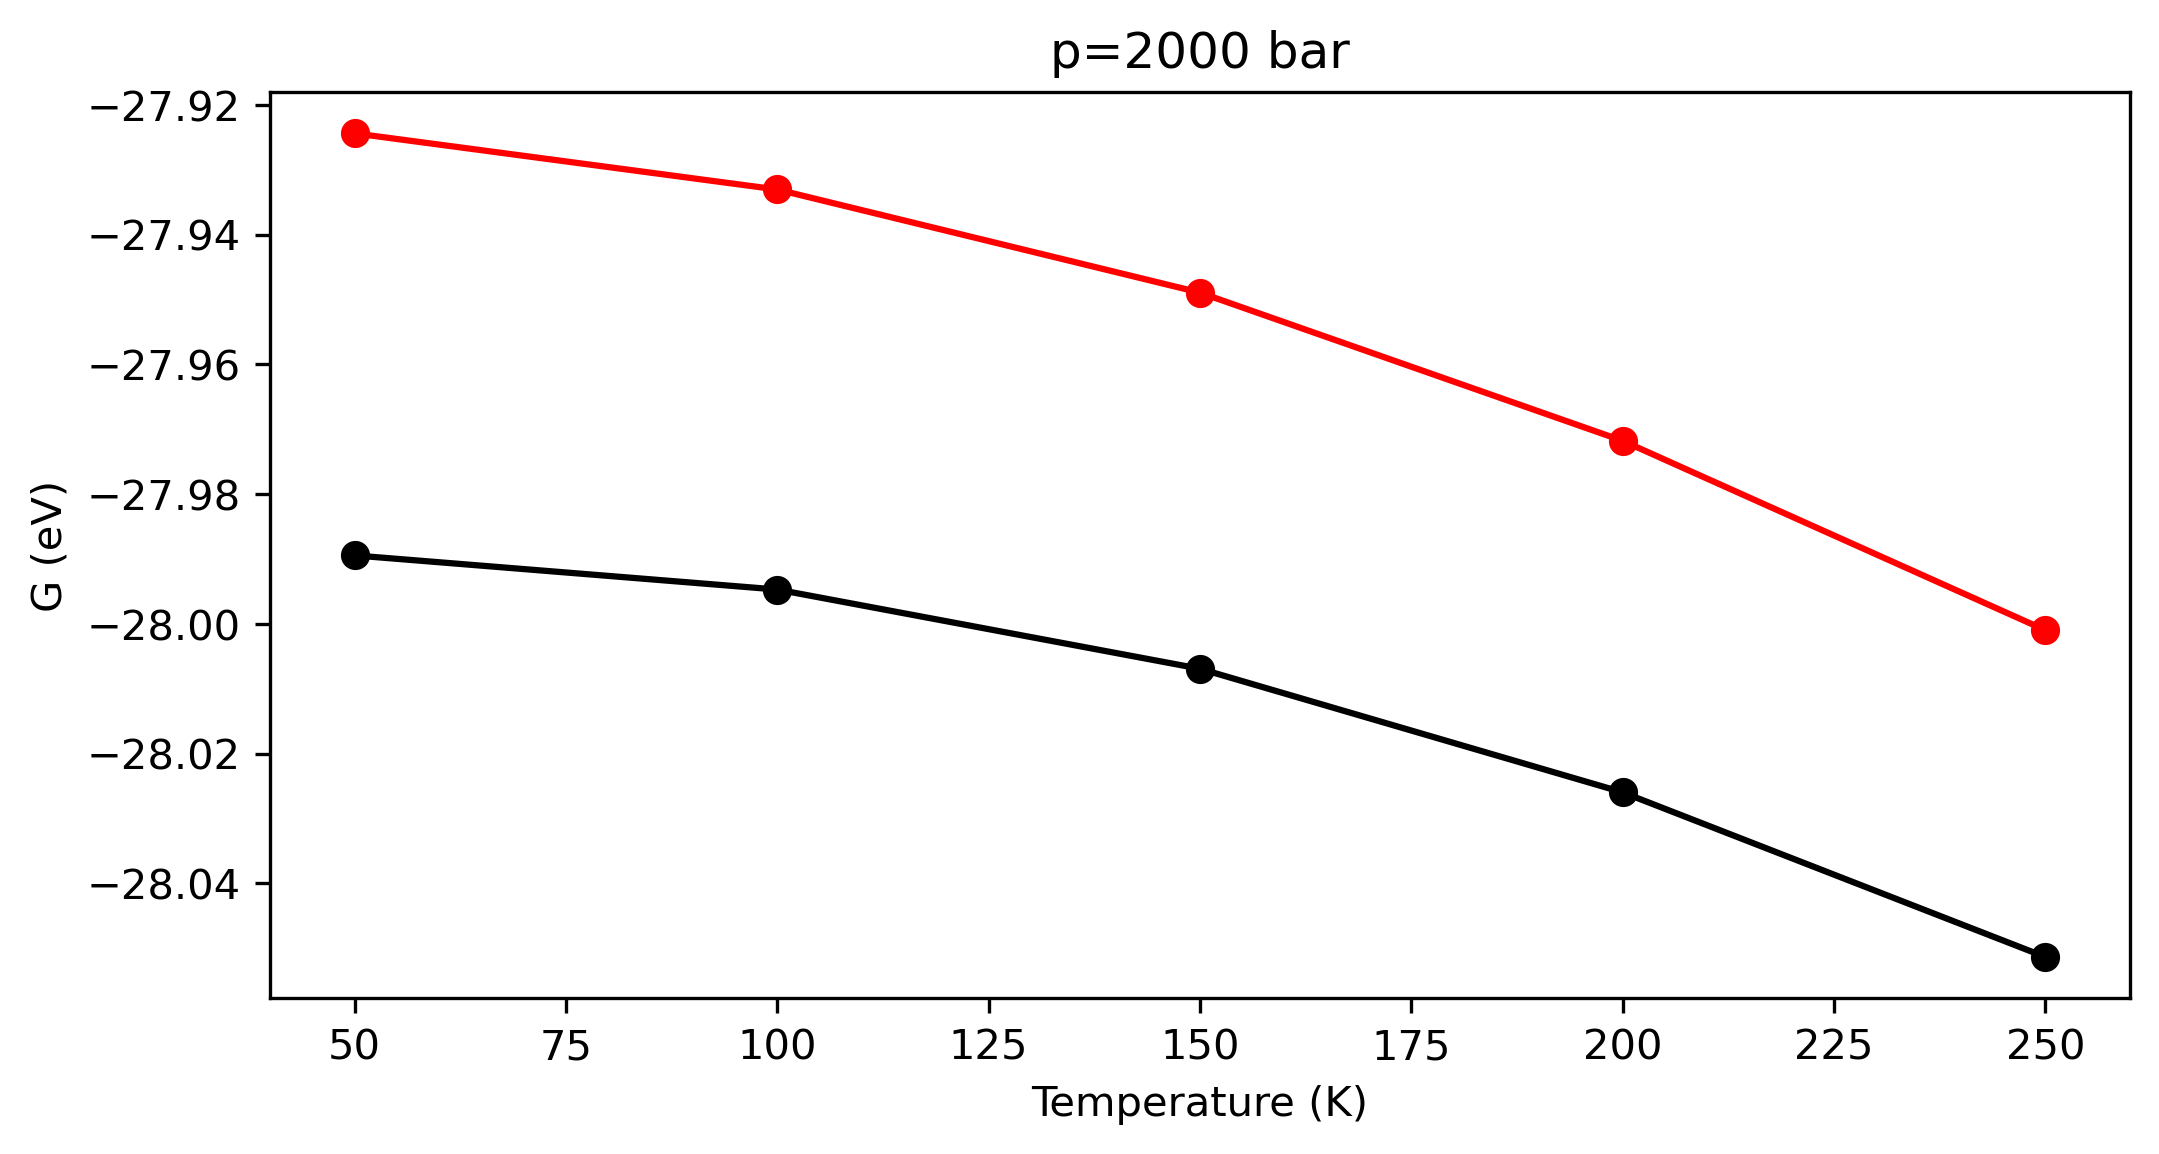

In [101]:
plt.figure(figsize=(8,4),dpi=300)
plt.plot(Gibbs_T[:,0], Gibbs_T[:,1],'ko-',label='II')
plt.plot(Gibbs_T_III[:,0], Gibbs_T_III[:,1]-Gibbs_T_III[:,0]*8.314*np.log(2)/1000/96.48,'ro-',label='III')
plt.xlabel('Temperature (K)')
plt.ylabel('G (eV)')
plt.title('p=2000 bar')

In [297]:
vol[:]/N

array([38.23502778, 38.08032953, 38.2079322 , 38.17379389, 37.5524608 ,
       37.69610456, 37.26624081, 37.37222813, 37.39242884, 37.36889498,
       37.31965585, 37.29488614, 36.9259225 , 37.04804855])

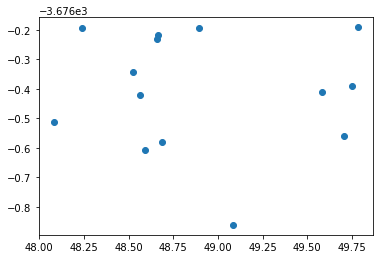

In [317]:
plt.plot(vol[:]/N,u,'o')

In [319]:
200*8.314*np.log(2)/1000

1.152565131835077

# Aharmonic

In [ ]:
U0_disorder=-10086.1063608947 #eV
U0_order=-10084.4328866352